<div style="border-left:4px solid #3D6FB0;padding:6px 0 8px 16px;"><div style="opacity:.72;font-size:12px;letter-spacing:1.4px;">Datos Masivos II · PRÁCTICA 2</div><div style="color:#3D6FB0;font-size:27px;font-weight:700;margin-top:4px;">Sección Titanic: EDA, Calidad y Preprocesamiento </div><div style="opacity:.72;font-size:14px;margin-top:6px;margin-bottom:10px;">Equipo Tres: Castrillo Cruz Karen Arlet, Ramos González Nadia, Zamora Antiga Ángel Javier.</div><img src="https://mmss.iimas.unam.mx/dmmss/wp-content/uploads/2026/02/cropped-LogoUNAM_IIMAS_Negro50-scaled-2.png" width="200"/></div>

### Objetivo

Preparar los datos del Titanic para la búsqueda de **patrones frecuentes y reglas de asociación** con FP-Growth (notebook 2). Este notebook perfila los datos, evalúa su calidad por dimensiones, limpia, reduce y transforma los atributos hasta obtener transacciones de ítems `Atributo=valor`. Cada decisión queda documentada junto con las alternativas descartadas.

### Los datos

Dataset *Titanic – Machine Learning from Disaster* de Kaggle: https://www.kaggle.com/competitions/titanic/data

Archivos: `train.csv` (con `Survived`), `test.csv` (sin `Survived`) y `gender_submission.csv` (ejemplo de formato de entrega).

### Autores

Equipo 3

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">CALIDAD · PREPARACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">0. Preparación y carga</span></div>

Se importan las librerías y se cargan los archivos originales de Kaggle para conocer el tamaño de cada tabla y su aspecto antes de decidir qué datos entran al análisis.

In [1]:
# Importación de librerías y carga de train.csv y test.csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)

RUTA_DATOS = Path("..") / "data"

train = pd.read_csv(RUTA_DATOS / "train.csv")
test = pd.read_csv(RUTA_DATOS / "test.csv")

for nombre, df in [("train", train), ("test", test)]:
    print(f"{nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    display(df.head())

train: 891 filas x 12 columnas


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


test: 418 filas x 11 columnas


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">CALIDAD · SELECCIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">1. Selección de datos</span></div>

Antes de perfilar se define qué archivos y qué columnas forman parte del análisis. Para reglas de asociación importa tanto lo que entra como lo que se deja fuera, porque cada fila es una transacción y cada columna se convertirá en ítems `Atributo=valor`.

#### Diccionario de datos (fuente: Kaggle)

| Variable | Definición | Codificación |
|---|---|---|
| `Survived` | Sobrevivió | 0 = No, 1 = Sí |
| `Pclass` | Clase del boleto | 1 = 1.ª, 2 = 2.ª, 3 = 3.ª |
| `Sex` | Sexo | |
| `Age` | Edad en años | |
| `SibSp` | N.º de hermanos/cónyuges a bordo | |
| `Parch` | N.º de padres/hijos a bordo | |
| `Ticket` | Número de boleto | |
| `Fare` | Tarifa pagada | |
| `Cabin` | Número de camarote | |
| `Embarked` | Puerto de embarque | C = Cherbourg, Q = Queenstown, S = Southampton |

**Notas sobre las variables**

- **Pclass:** aproximación al nivel socioeconómico. 1.ª = alto, 2.ª = medio, 3.ª = bajo.
- **Age:** es fraccionaria si es menor que 1. Si la edad es **estimada**, aparece en la forma xx.5.
- **SibSp:** hermano = hermano, hermana, hermanastro o hermanastra. Cónyuge = esposo o esposa (se ignoraron amantes y prometidos).
- **Parch:** padre = madre o padre. Hijo = hija, hijo, hijastra o hijastro. Algunos niños viajaron solo con una niñera, por lo que para ellos `Parch = 0`.

> **Nota:** `PassengerId` y `Name` no aparecen en el diccionario: son un identificador y un nombre, respectivamente.

#### Archivos: qué se usa y qué se descarta

| Archivo | Filas | Decisión | Motivo |
|---|---|---|---|
| `train.csv` | 891 | **Se usa** | Es la única tabla con `Survived`, el ítem que hace interesantes las reglas (p. ej. `{Sex=female, Pclass=1} → Survived=1`). |
| `test.csv` | 418 | **Se descarta** | No tiene `Survived`. Añadir sus 418 filas aumentaría el total de transacciones a 1309 sin aportar ese ítem, lo que **diluye el soporte** de cualquier itemset que contenga `Survived` (como máximo 891/1309 ≈ 68 % de las transacciones podrían contenerlo). |
| `gender_submission.csv` | 418 | **Se descarta** | Es el ejemplo de formato de entrega de Kaggle: una *predicción* (mujer → sobrevive, hombre → no) para `test`, no la verdad. Usarla para completar `Survived` fabricaría la regla `Sex=female → Survived=1` con confianza del 100 % en esas filas. Es un problema de **exactitud y validez**, no un dato. |

#### Columnas: selección provisional

**Decisión:** conservar las 12 columnas de `train` durante el perfilado y clasificarlas por rol. La selección definitiva de atributos (qué se deriva de `Name` y `Ticket`, qué se hace con `Cabin`) se toma en las secciones 4–6 con evidencia del perfilado y de la prueba chi-cuadrado.

**Alternativa descartada:** fijar ya la lista final y eliminar `Name`, `Ticket` y `Cabin` sin derivados. Es más simple, pero se decidiría sin evidencia y se perderían atributos potencialmente útiles: `Title` (de `Name`), que sirve para imputar `Age` por grupo, y el tamaño de grupo (de `Ticket`).

In [2]:
# Clasificación provisional de las columnas de train por rol
roles = {
    "PassengerId": ("Identificador", "No", "Clave de fila; único por pasajero, no aporta patrones."),
    "Survived":    ("Atributo", "Sí", "Ítem central: consecuente de interés en las reglas."),
    "Pclass":      ("Atributo", "Sí", "Categórica ordinal (1, 2, 3)."),
    "Name":        ("Identificador", "No", "Posible derivado: Title (Mr, Mrs, Miss, Master...)."),
    "Sex":         ("Atributo", "Sí", "Categórica binaria."),
    "Age":         ("Atributo", "Sí", "Numérica: requiere imputación y binning."),
    "SibSp":       ("Atributo", "Sí", "Conteo: revisar rango y posible agrupación."),
    "Parch":       ("Atributo", "Sí", "Conteo: revisar rango y posible agrupación."),
    "Ticket":      ("Identificador", "No", "Posible derivado: tamaño de grupo por ticket compartido."),
    "Fare":        ("Atributo", "Sí", "Numérica: requiere binning; revisar Fare = 0 y outliers."),
    "Cabin":       ("Por decidir", "Por decidir", "Opciones: descartar, Deck o TieneCabina (ojo con redundancia con Pclass)."),
    "Embarked":    ("Atributo", "Sí", "Categórica (C, Q, S)."),
}

tabla_roles = pd.DataFrame(
    [(col, str(train[col].dtype), *roles[col]) for col in train.columns],
    columns=["Columna", "Tipo", "Rol", "¿Ítem?", "Nota"],
)
display(tabla_roles.style.hide(axis="index"))
print(tabla_roles["Rol"].value_counts().to_string())

Columna,Tipo,Rol,¿Ítem?,Nota
PassengerId,int64,Identificador,No,"Clave de fila; único por pasajero, no aporta patrones."
Survived,int64,Atributo,Sí,Ítem central: consecuente de interés en las reglas.
Pclass,int64,Atributo,Sí,"Categórica ordinal (1, 2, 3)."
Name,object,Identificador,No,"Posible derivado: Title (Mr, Mrs, Miss, Master...)."
Sex,object,Atributo,Sí,Categórica binaria.
Age,float64,Atributo,Sí,Numérica: requiere imputación y binning.
SibSp,int64,Atributo,Sí,Conteo: revisar rango y posible agrupación.
Parch,int64,Atributo,Sí,Conteo: revisar rango y posible agrupación.
Ticket,object,Identificador,No,Posible derivado: tamaño de grupo por ticket compartido.
Fare,float64,Atributo,Sí,Numérica: requiere binning; revisar Fare = 0 y outliers.


Rol
Atributo         8
Identificador    3
Por decidir      1


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">CALIDAD · PERFILADO</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">2. Perfilado</span></div>

Se perfila `train` para conocer la estructura de cada columna (tipos, cardinalidad y rangos) y sus problemas de calidad: completitud, unicidad, validez y outliers. En esta sección **solo se detecta y se anota**; las correcciones se deciden en la sección 4.

In [3]:
# Perfilado estructural de train: tipos, cardinalidad y rangos
def resumen_calidad(df, nombre):
    """
    Genera un resumen estructural de calidad de un DataFrame.

    Parámetros
    ----------
    df : pd.DataFrame
        Tabla a perfilar.
    nombre : str
        Nombre de la tabla, usado en el mensaje de cabecera.

    Retorna
    -------
    pd.DataFrame
        Una fila por columna con tipo, nulos, % de nulos, valores únicos,
        mínimo y máximo (estos dos solo en columnas numéricas).
    """
    print(f"Tabla {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas")
    numericas = df.select_dtypes("number")
    return pd.DataFrame({
        "Tipo": df.dtypes.astype(str),
        "Nulos": df.isna().sum(),
        "% nulos": (df.isna().mean() * 100).round(2),
        "Únicos": df.nunique(),
        "Mín": numericas.min(),
        "Máx": numericas.max(),
    }).reindex(df.columns).rename_axis("Columna")


perfil_train = resumen_calidad(train, "train")
display(perfil_train.style.format({"% nulos": "{:.2f}", "Mín": "{:g}", "Máx": "{:g}"}, na_rep="—"))

Tabla train: 891 filas x 12 columnas


,Tipo,Nulos,% nulos,Únicos,Mín,Máx
Columna,,,,,,
PassengerId,int64,0,0.00,891,1,891
Survived,int64,0,0.00,2,0,1
Pclass,int64,0,0.00,3,1,3
Name,object,0,0.00,891,—,—
Sex,object,0,0.00,2,—,—
Age,float64,177,19.87,88,0.42,80
SibSp,int64,0,0.00,7,0,8
Parch,int64,0,0.00,7,0,6
Ticket,object,0,0.00,681,—,—


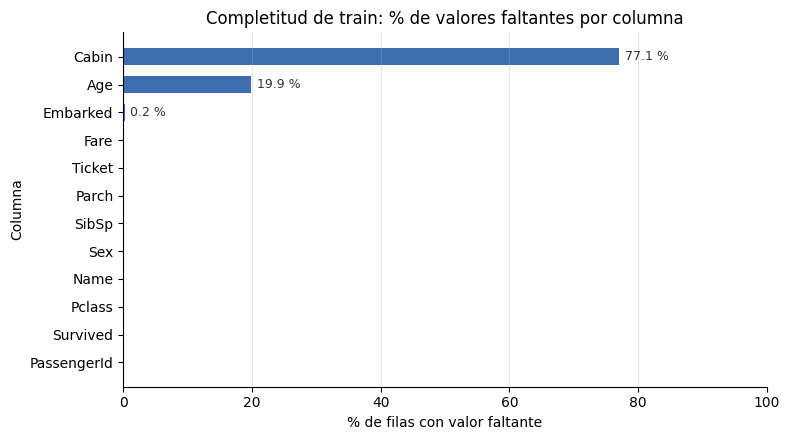

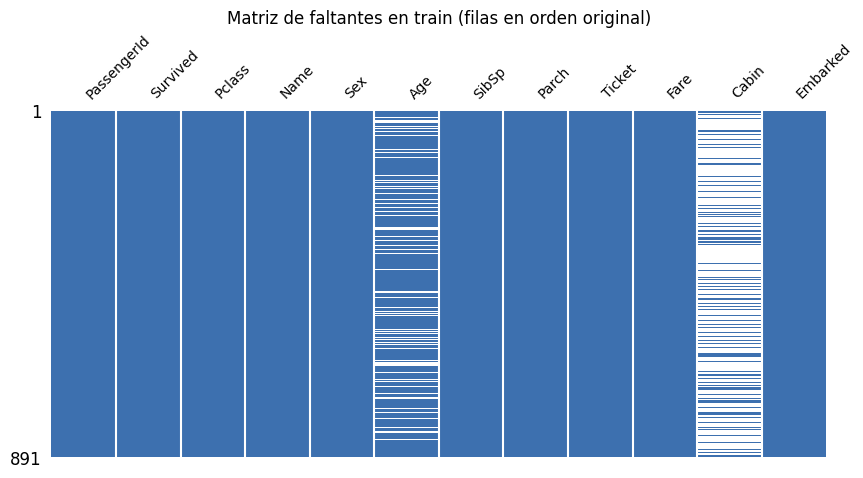

In [4]:
# Completitud: % de nulos por columna y matriz de faltantes
import missingno as msno

AZUL = "#3D6FB0"

pct_nulos = perfil_train["% nulos"].sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
barras = ax.barh(pct_nulos.index, pct_nulos.values, color=AZUL, height=0.6)
ax.bar_label(barras, labels=[f"{v:.1f} %" if v > 0 else "" for v in pct_nulos.values],
             padding=4, fontsize=9, color="#333333")
ax.set_title("Completitud de train: % de valores faltantes por columna")
ax.set_xlabel("% de filas con valor faltante")
ax.set_ylabel("Columna")
ax.set_xlim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Matriz de faltantes: cada línea blanca es un valor ausente en esa fila
ax_m = msno.matrix(train, figsize=(10, 4.5), fontsize=10, sparkline=False, color=(0.24, 0.44, 0.69))
ax_m.set_title("Matriz de faltantes en train (filas en orden original)", fontsize=12)
plt.show()

**Observaciones: tipos, cardinalidad, rangos y completitud**

- **Solo 3 de las 12 columnas tienen faltantes:**
  - **Cabin**: 687 nulos (**77.10 %**);
  - **Age**: 177 nulos (**19.87 %**);
  - **Embarked**: 2 nulos (**0.22 %**).
  
  El resto está completo.
- En la matriz de `missingno`, los faltantes de Age y Cabin aparecen **dispersos**, sin bloques. Esto es esperable, porque el orden de las filas no tiene significado. La matriz no dice si los faltantes dependen de la clase; eso se cruza explícitamente más adelante.
- **PassengerId y Name tienen 891 valores únicos**, uno por fila: son identificadores y no sirven como ítems.
- **Ticket tiene 681 valores únicos para 891 filas**, así que hay boletos compartidos. Se analiza en *Unicidad*.
- **Cabin tiene 147 valores distintos entre 204 no nulos.** Como ítem directo casi cada valor tendría soporte de una sola transacción. Si se conserva, tiene que ser como un derivado (Deck o TieneCabina).
- **Rangos:**
  - **Fare** va de **0** a **512.33**: el mínimo de 0 se revisa en *Validez* y el máximo es candidato a outlier.
  - **Age** va de **0.42** a **80**: el mínimo fraccionario es coherente con el diccionario.
  - **SibSp** llega a **8** y **Parch** a **6**, con 7 valores distintos cada uno.
- **Decisiones que alimenta:** la imputación de Age y Embarked y el tratamiento de Cabin (sección 4); la derivación del tamaño de grupo desde Ticket (sección 6). *(Resuelto: Age y Embarked imputados y Cabin descartada en la sección 4; el tamaño de grupo se derivó de `FamilySize`, no de Ticket, en la sección 5.)*

In [5]:
# Unicidad: claves duplicadas y boletos compartidos
print(f"PassengerId duplicados: {train['PassengerId'].duplicated().sum()}")
print(f"Name duplicados: {train['Name'].duplicated().sum()}")
print(f"Filas completas duplicadas (sin PassengerId): {train.drop(columns='PassengerId').duplicated().sum()}")

# Tamaño de grupo por ticket: cuántos pasajeros de train comparten cada boleto
tam_ticket = train.groupby("Ticket")["PassengerId"].transform("size")
dist_grupo = (
    tam_ticket.value_counts().sort_index()
    .rename("Pasajeros").to_frame()
    .assign(**{"Boletos": lambda d: d["Pasajeros"] // d.index,
               "% pasajeros": lambda d: (d["Pasajeros"] / len(train) * 100).round(2)})
    .rename_axis("Pasajeros por boleto")
)
display(dist_grupo)
print(f"Pasajeros que comparten boleto: {(tam_ticket > 1).sum()} de {len(train)} "
      f"({(tam_ticket > 1).mean() * 100:.2f} %)")

PassengerId duplicados: 0
Name duplicados: 0
Filas completas duplicadas (sin PassengerId): 0


,Pasajeros,Boletos,% pasajeros
Pasajeros por boleto,,,
1,547,547,61.39
2,188,94,21.10
3,63,21,7.07
4,44,11,4.94
5,10,2,1.12
6,18,3,2.02
7,21,3,2.36


Pasajeros que comparten boleto: 344 de 891 (38.61 %)


In [6]:
# Validez: Fare = 0, edades fraccionarias/estimadas, rangos de SibSp y Parch, niños con Parch = 0
# Fare = 0
fare_cero = train[train["Fare"] == 0]
print(f"Pasajeros con Fare = 0: {len(fare_cero)}")
display(fare_cero[["PassengerId", "Name", "Pclass", "Age", "Ticket", "Fare", "Embarked"]])

# Age: menores de 1 (fraccionarias) y forma xx.5 (estimadas según el diccionario)
edad = train["Age"].dropna()
menor_1 = edad < 1
forma_x5 = (edad % 1) == 0.5
print(f"Edades registradas: {len(edad)}")
print(f"  Menores que 1: {menor_1.sum()} -> {sorted(edad[menor_1].tolist())}")
print(f"  Con forma xx.5: {forma_x5.sum()} (de ellas menores que 1: {(menor_1 & forma_x5).sum()})")
print(f"  Estimadas (xx.5 y >= 1): {(forma_x5 & ~menor_1).sum()} -> {sorted(edad[forma_x5 & ~menor_1].tolist())}")
print(f"  Otras no enteras: {((edad % 1 != 0) & ~menor_1 & ~forma_x5).sum()}")

# Frecuencias de SibSp y Parch
frec = pd.concat(
    {col: train[col].value_counts().sort_index() for col in ["SibSp", "Parch"]}, axis=1
).fillna(0).astype(int).sort_index().rename_axis("Valor")
display(frec)

# Niños (Age < 18) con Parch = 0: según el diccionario, viajaban con niñera; no es un error
ninos = train[train["Age"] < 18]
ninos_sin_padres = ninos[ninos["Parch"] == 0]
print(f"Niños (Age < 18): {len(ninos)}; con Parch = 0: {len(ninos_sin_padres)} "
      f"({len(ninos_sin_padres) / len(ninos) * 100:.2f} %)")
print(ninos_sin_padres["Age"].describe()[["min", "50%", "max"]].to_string())

Pasajeros con Fare = 0: 15


,PassengerId,Name,Pclass,Age,Ticket,Fare,Embarked
179,180,"Leonard, Mr. Lionel",3,36.0,LINE,0.0,S
263,264,"Harrison, Mr. William",1,40.0,112059,0.0,S
271,272,"Tornquist, Mr. William Henry",3,25.0,LINE,0.0,S
277,278,"Parkes, Mr. Francis ""Frank""",2,NaN,239853,0.0,S
302,303,"Johnson, Mr. William Cahoone Jr",3,19.0,LINE,0.0,S
413,414,"Cunningham, Mr. Alfred Fleming",2,NaN,239853,0.0,S
466,467,"Campbell, Mr. William",2,NaN,239853,0.0,S
481,482,"Frost, Mr. Anthony Wood ""Archie""",2,NaN,239854,0.0,S
597,598,"Johnson, Mr. Alfred",3,49.0,LINE,0.0,S
633,634,"Parr, Mr. William Henry Marsh",1,NaN,112052,0.0,S


Edades registradas: 714
  Menores que 1: 7 -> [0.42, 0.67, 0.75, 0.75, 0.83, 0.83, 0.92]
  Con forma xx.5: 18 (de ellas menores que 1: 0)
  Estimadas (xx.5 y >= 1): 18 -> [14.5, 20.5, 23.5, 24.5, 28.5, 28.5, 30.5, 30.5, 32.5, 32.5, 34.5, 36.5, 40.5, 40.5, 45.5, 45.5, 55.5, 70.5]
  Otras no enteras: 0


,SibSp,Parch
Valor,,
0,608,678
1,209,118
2,28,80
3,16,5
4,18,4
5,5,5
6,0,1
8,7,0


Niños (Age < 18): 113; con Parch = 0: 32 (28.32 %)
min     5.0
50%    16.0
max    17.0


**Observaciones: unicidad y validez**

- **Unicidad:**
  - **0** `PassengerId` duplicados, **0** `Name` duplicados y **0** filas completas duplicadas (sin `PassengerId`). No hay registros repetidos que eliminar.
  - **344 de 891 pasajeros (38.61 %) comparten boleto**, en grupos de 2 a 7 personas. Por ejemplo, 188 pasajeros (21.10 %) están en boletos de 2. Esto respalda derivar un atributo de tamaño de grupo a partir de `Ticket`.
  - Ojo: el tamaño se calculó solo dentro de `train`, así que puede **subestimarse**, porque hay pasajeros de `test` que comparten boleto.
- **Fare = 0 en 15 pasajeros**, todos hombres embarcados en S y repartidos en las tres clases (5 en 1.ª, 6 en 2.ª, 4 en 3.ª).
  - Hay patrones de grupo: 4 tienen el boleto literal `LINE` y otros comparten números consecutivos (`239853`–`239856`, `112050`–`112059`).
  - Esto apunta a **boletos sin costo** más que a errores de captura.
  - Sin tratamiento, un pasajero de 1.ª clase con Fare = 0 caería en el bin más bajo de tarifa. *Alimenta una decisión de la sección 4.*
- **Age:**
  - **7 edades son menores que 1** (de 0.42 a 0.92), coherente con el diccionario.
  - **18 tienen la forma xx.5** (de 14.5 a 70.5), es decir, son **estimadas**: el 2.52 % de las 714 edades registradas.
  - No hay otras edades no enteras. Con bins de varios años, el efecto de las estimadas es despreciable: se documenta y no se corrige.
- **SibSp y Parch:** casi todo se concentra en 0 y 1.
  - SibSp = 0 en 608 pasajeros y Parch = 0 en 678.
  - Los valores altos son raros: **SibSp ≥ 3 suma 46 pasajeros (5.16 %)** y **Parch ≥ 3 suma 15 (1.68 %)**.
  - Con soportes mínimos del 5–10 %, esos ítems no entrarían en ningún itemset frecuente. *Alimenta la agrupación de la sección 6.*
- **Niños (`Age < 18`) con `Parch = 0`: 32 de 113 (28.32 %)**, con edades de 5 a 17 y mediana de 16. En su mayoría son adolescentes, no niños pequeños. Según el diccionario **no es un error** (algunos viajaban con niñera): se documenta y no se corrige.

### EDA visual (datos crudos)

Exploración gráfica de `train` **sin imputar ni transformar**. Cada gráfica alimenta una decisión posterior: cortes de binning, tratamiento de outliers, agrupación de ítems raros, estrategia de imputación o redundancia entre atributos. Las relaciones entre pares de variables categóricas (V de Cramér y chi-cuadrado) se analizan en la **sección 5**, cuando ya existan los atributos derivados (Title, Deck, tamaño de grupo).

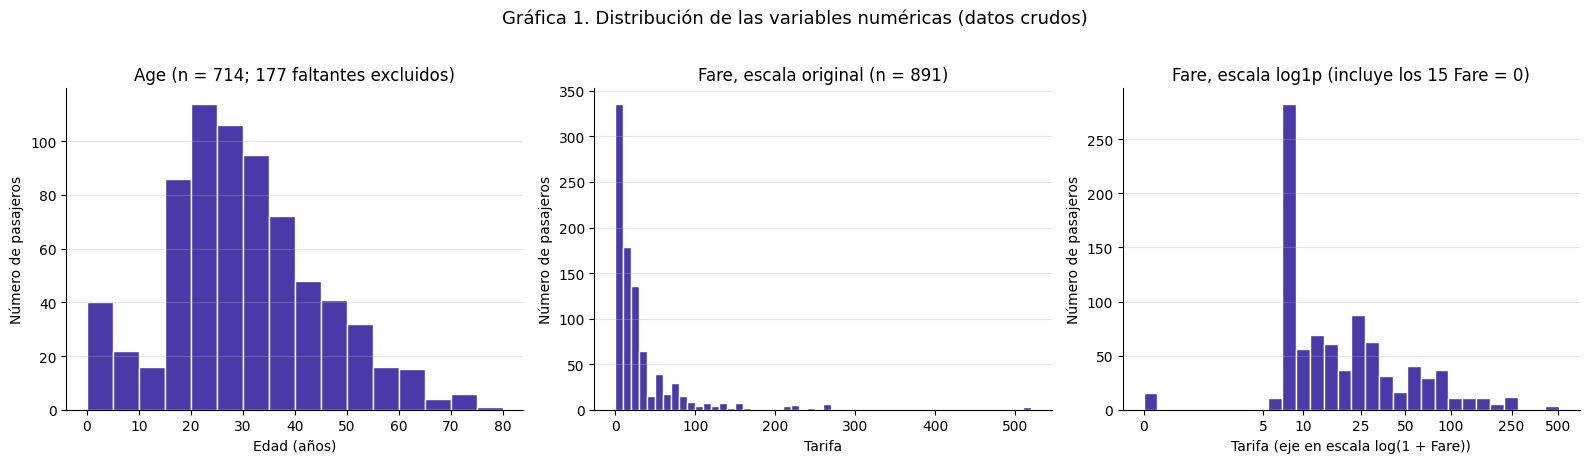

,count,mean,std,min,10%,25%,50%,75%,90%,max
Age,714.0,29.7,14.53,0.42,14.00,20.12,28.00,38.0,50.00,80.00
Fare,891.0,32.2,49.69,0.00,7.55,7.91,14.45,31.0,77.96,512.33


In [7]:
# Gráfica 1: distribución de Age y Fare (Fare también en escala log1p)
COLOR_G1 = "#4a3aa7"  # violeta
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Age: bins de 5 años, sin faltantes
edad = train["Age"].dropna()
axes[0].hist(edad, bins=range(0, 85, 5), color=COLOR_G1, edgecolor="white")
axes[0].set_title(f"Age (n = {len(edad)}; {train['Age'].isna().sum()} faltantes excluidos)")
axes[0].set_xlabel("Edad (años)")
axes[0].set_ylabel("Número de pasajeros")
axes[0].set_xticks(range(0, 85, 10))

# Fare: escala original, bins de 10
axes[1].hist(train["Fare"], bins=range(0, 530, 10), color=COLOR_G1, edgecolor="white")
axes[1].set_title(f"Fare, escala original (n = {len(train)})")
axes[1].set_xlabel("Tarifa")
axes[1].set_ylabel("Número de pasajeros")

# Fare: escala log1p, con marcas etiquetadas en la tarifa original para interpretarla
axes[2].hist(np.log1p(train["Fare"]), bins=30, color=COLOR_G1, edgecolor="white")
marcas = [0, 5, 10, 25, 50, 100, 250, 500]
axes[2].set_xticks(np.log1p(marcas), labels=marcas)
axes[2].set_title("Fare, escala log1p (incluye los 15 Fare = 0)")
axes[2].set_xlabel("Tarifa (eje en escala log(1 + Fare))")
axes[2].set_ylabel("Número de pasajeros")

for ax in axes:
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("Gráfica 1. Distribución de las variables numéricas (datos crudos)", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Resumen numérico de apoyo para los cortes de binning
display(train[["Age", "Fare"]].describe(percentiles=[.1, .25, .5, .75, .9]).T.round(2))

**Observaciones, gráfica 1: distribución de Age y Fare**

- **Age** (714 registradas, 177 faltantes excluidas):
  - Distribución con cola a la derecha: media **29.70**, mediana **28.00**. El intervalo más poblado es el de **20–25 años**.
  - Los menores de 5 años forman un **pico propio** separado del intervalo 5–15. Los niños pequeños son un grupo visible.
  - La cola superior es escasa: el p90 es **50** y el máximo **80**.
  - Los cuartiles (**20.12, 28, 38**) darían cortes poco legibles en una regla.
  - *Alimenta la sección 6:* cortes de dominio (niño, joven, adulto, mayor) frente a cuantiles.
- **Fare** (891 registros):
  - Asimetría extrema: media **32.20** contra mediana **14.45**. El **25 % paga ≤ 7.91**, el p90 es **77.96** y el máximo **512.33**.
  - En escala original casi todo se concentra en las primeras barras.
  - La escala **log1p** muestra:
    - un pico dominante alrededor de 8 (tarifas de 3.ª);
    - la barra aislada de los 15 Fare = 0;
    - varias concentraciones secundarias hacia 13, 26 y 50–100, posiblemente asociadas a la clase (se revisa en la gráfica 7).
  - *Alimenta la sección 6:* los intervalos de ancho fijo dejarían casi todos los pasajeros en el primero. Fare necesita **cuantiles o cortes de dominio**, y la cola alta (outliers) quedará absorbida en el último intervalo.

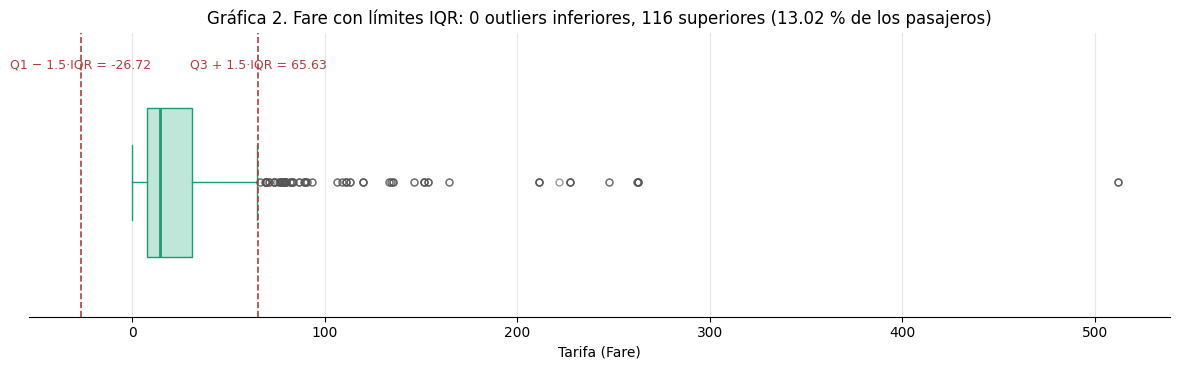

Q1 = 7.91, Q3 = 31.00, IQR = 23.09


,Outliers,Pasajeros en la clase,% de la clase,% de los outliers
Pclass,,,,
1,104,216,48.15,89.66
2,5,184,2.72,4.31
3,7,491,1.43,6.03


,min,50%,max
Fare de los outliers,66.6,90.0,512.33


In [8]:
# Gráfica 2: boxplot horizontal de Fare con límites IQR y conteo de outliers
q1, q3 = train["Fare"].quantile([0.25, 0.75])
iqr = q3 - q1
lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
es_out_inf = train["Fare"] < lim_inf
es_out_sup = train["Fare"] > lim_sup

COLOR_G2 = "#199e70"  # aguamarina oscuro
fig, ax = plt.subplots(figsize=(12, 3.8))
ax.boxplot(train["Fare"], vert=False, whis=1.5, widths=0.5, patch_artist=True,
           boxprops=dict(facecolor="#BFE6D8", edgecolor=COLOR_G2),
           medianprops=dict(color=COLOR_G2, linewidth=2),
           whiskerprops=dict(color=COLOR_G2), capprops=dict(color=COLOR_G2),
           flierprops=dict(marker="o", markersize=5, markerfacecolor="none", markeredgecolor="#555555", alpha=0.6))
for x, txt in [(lim_inf, f"Q1 − 1.5·IQR = {lim_inf:.2f}"), (lim_sup, f"Q3 + 1.5·IQR = {lim_sup:.2f}")]:
    ax.axvline(x, color="#B03D3D", linestyle="--", linewidth=1.2)
    ax.text(x, 1.38, txt, color="#B03D3D", fontsize=9, ha="center")
ax.set_ylim(0.55, 1.5)
ax.set_yticks([])
ax.set_xlabel("Tarifa (Fare)")
ax.set_title(f"Gráfica 2. Fare con límites IQR: {es_out_inf.sum()} outliers inferiores, "
             f"{es_out_sup.sum()} superiores ({es_out_sup.mean() * 100:.2f} % de los pasajeros)")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Q1 = {q1:.2f}, Q3 = {q3:.2f}, IQR = {iqr:.2f}")

# Outliers superiores por clase: cuántos hay y qué fracción de cada clase representan
out_clase = pd.DataFrame({
    "Outliers": train[es_out_sup].groupby("Pclass").size(),
    "Pasajeros en la clase": train.groupby("Pclass").size(),
}).fillna(0).astype(int)
out_clase["% de la clase"] = (out_clase["Outliers"] / out_clase["Pasajeros en la clase"] * 100).round(2)
out_clase["% de los outliers"] = (out_clase["Outliers"] / es_out_sup.sum() * 100).round(2)
display(out_clase)
display(train.loc[es_out_sup, "Fare"].describe()[["min", "50%", "max"]].round(2).to_frame("Fare de los outliers").T)

**Observaciones, gráfica 2: outliers de Fare con IQR**

- **Límites:** Q1 = **7.91**, Q3 = **31.00** e IQR = **23.09**, de modo que el límite inferior es **−26.72** y el superior **65.63**.
- **No hay outliers inferiores (0).** El límite inferior es negativo, imposible para una tarifa.
- **Hay 116 outliers superiores (13.02 % de los pasajeros)**, con Fare entre **66.60** y **512.33** (mediana 90.00). El máximo, 512.33, está muy separado del resto de la cola.
- **Los outliers son, sobre todo, la 1.ª clase:** 104 de los 116 (**89.66 %**) viajan en 1.ª, y **el 48.15 % de toda la 1.ª clase** queda marcado como outlier. En 2.ª hay 5 (2.72 % de la clase) y en 3.ª hay 7 (1.43 %).
- **Interpretación:** el IQR se calcula sobre una mezcla de tres clases con tarifas muy distintas. Lo que señala es la cola de una subpoblación legítima, no errores.
  - Eliminarlos borraría casi la mitad de la 1.ª clase y sesgaría cualquier regla con `Pclass=1`.
  - *Alimenta la sección 6:* los outliers **no se eliminan**, quedan absorbidos en el último intervalo de Fare.
- **El IQR no detecta los 15 Fare = 0**, porque el límite inferior es negativo. Un problema de **validez** puede pasar inadvertido para un método estadístico de outliers. Se detectó con una regla de dominio (Fare > 0) en la sección de validez.

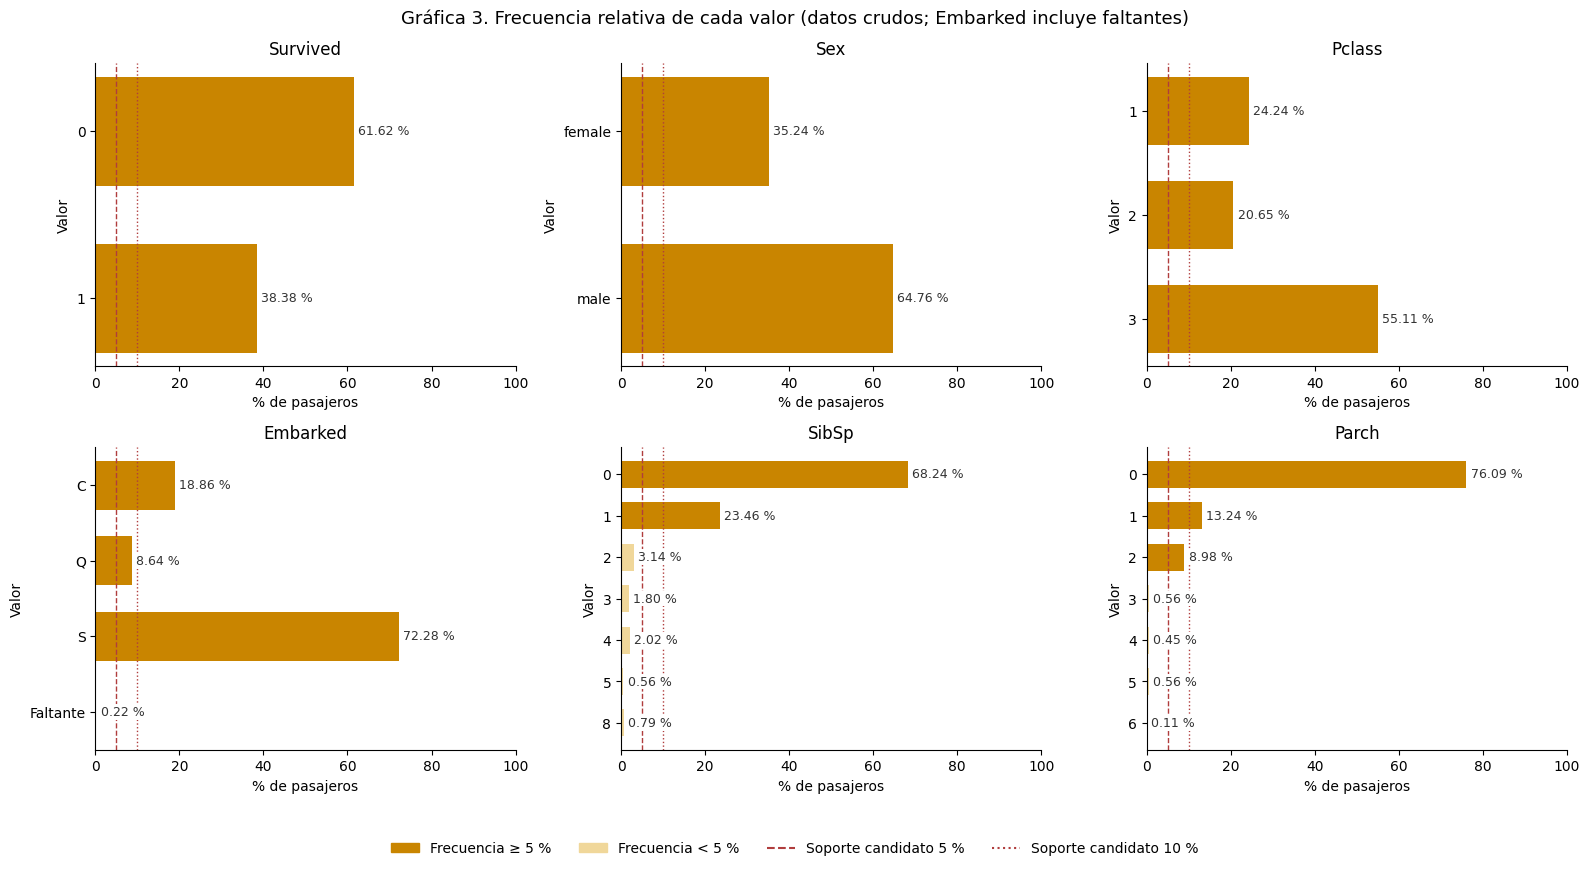

,Valores,Valor dominante,Valores < 5 %,Valores < 10 %
Variable,,,,
Survived,2,0 (61.62 %),0,0
Sex,2,male (64.76 %),0,0
Pclass,3,3 (55.11 %),0,0
Embarked,4,S (72.28 %),1,2
SibSp,7,0 (68.24 %),5,5
Parch,7,0 (76.09 %),4,5


In [9]:
# Gráfica 3: frecuencia relativa de las variables categóricas (ítems dominantes y raros)
COLOR_G3 = "#c98500"  # amarillo oscuro (frecuencia >= 5 %)
COLOR_G3_CLARO = "#F0D79A"  # amarillo claro (frecuencia < 5 %)
variables = ["Survived", "Sex", "Pclass", "Embarked", "SibSp", "Parch"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
for ax, col in zip(axes.flat, variables):
    frec_rel = train[col].value_counts(dropna=False, normalize=True).mul(100)
    frec_rel.index = ["Faltante" if pd.isna(v) else str(v) for v in frec_rel.index]
    orden = sorted([v for v in frec_rel.index if v != "Faltante"], key=lambda v: (not v.isdigit(), int(v) if v.isdigit() else v))
    frec_rel = frec_rel.reindex(orden + (["Faltante"] if "Faltante" in frec_rel.index else []))

    colores = [COLOR_G3 if v >= 5 else COLOR_G3_CLARO for v in frec_rel.values]
    barras = ax.barh(frec_rel.index, frec_rel.values, color=colores, height=0.65)
    ax.axvline(5, color="#B03D3D", linestyle="--", linewidth=1)
    ax.axvline(10, color="#B03D3D", linestyle=":", linewidth=1)
    etiquetas = ax.bar_label(barras, labels=[f"{v:.2f} %" for v in frec_rel.values], padding=3, fontsize=9, color="#333333")
    for et in etiquetas:
        et.set_bbox(dict(facecolor="white", edgecolor="none", pad=1))
    ax.invert_yaxis()
    ax.set_xlim(0, 100)
    ax.set_title(col)
    ax.set_xlabel("% de pasajeros")
    ax.set_ylabel("Valor")
    ax.spines[["top", "right"]].set_visible(False)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
fig.legend(handles=[Patch(color=COLOR_G3, label="Frecuencia ≥ 5 %"), Patch(color=COLOR_G3_CLARO, label="Frecuencia < 5 %"),
                    Line2D([], [], color="#B03D3D", linestyle="--", label="Soporte candidato 5 %"),
                    Line2D([], [], color="#B03D3D", linestyle=":", label="Soporte candidato 10 %")],
           loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("Gráfica 3. Frecuencia relativa de cada valor (datos crudos; Embarked incluye faltantes)", fontsize=13)
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()

# Resumen: valores por debajo de los soportes candidatos
filas = []
for col in variables:
    fr = train[col].value_counts(dropna=False, normalize=True).mul(100)
    filas.append({"Variable": col, "Valores": len(fr),
                  "Valor dominante": f"{fr.index[0]} ({fr.iloc[0]:.2f} %)",
                  "Valores < 5 %": int((fr < 5).sum()), "Valores < 10 %": int((fr < 10).sum())})
display(pd.DataFrame(filas).set_index("Variable"))

**Observaciones, gráfica 3: frecuencia relativa de las variables categóricas**

- **Seis valores dominan con más del 50 %:**
  - `Parch=0` (**76.09 %**), `Embarked=S` (**72.28 %**) y `SibSp=0` (**68.24 %**);
  - `Sex=male` (**64.76 %**), `Survived=0` (**61.62 %**) y `Pclass=3` (**55.11 %**).
  
  Sus combinaciones tendrán soporte alto, así que muchos itemsets frecuentes serán mezclas de estos ítems "de fondo". Además, cualquier regla con uno de ellos como consecuente tendrá una confianza alta por defecto: por ejemplo, `X → Embarked=S` rondará el 72 % sin que exista asociación. *Alimenta el notebook 2:* el **lift** es imprescindible para separar asociación real de frecuencia base.
- **Survived está desbalanceado (61.62 % contra 38.38 %).** La confianza base de una regla con consecuente `Survived=1` es 38.38 %. Una regla `→ Survived=1` con confianza del 60 % es mucho más informativa que una `→ Survived=0` con la misma confianza.
- **Hay valores entre el 5 % y el 10 %: `Embarked=Q` (8.64 %) y `Parch=2` (8.98 %).** Con soporte mínimo de 10 % desaparecerían de todos los itemsets. *Alimenta el análisis de sensibilidad del soporte en el notebook 2.*
- **Valores por debajo del 5 %:**
  - `Embarked=Faltante` (0.22 %);
  - **5 valores de SibSp** (2, 3, 4, 5 y 8, de 3.14 % a 0.56 %);
  - **4 valores de Parch** (3, 4, 5 y 6, de 0.56 % a 0.11 %).
  
  Sin agrupar, nunca formarían parte de un itemset frecuente. *Alimenta la sección 6:* agrupar los conteos altos (p. ej. en `0 / 1 / 2+`) o derivar un atributo de tamaño de familia. *(Resuelto en la sección 5: `SibSp` y `Parch` se reemplazaron por `FamilySize` agrupado en Solo / 2-4 / 5+.)*

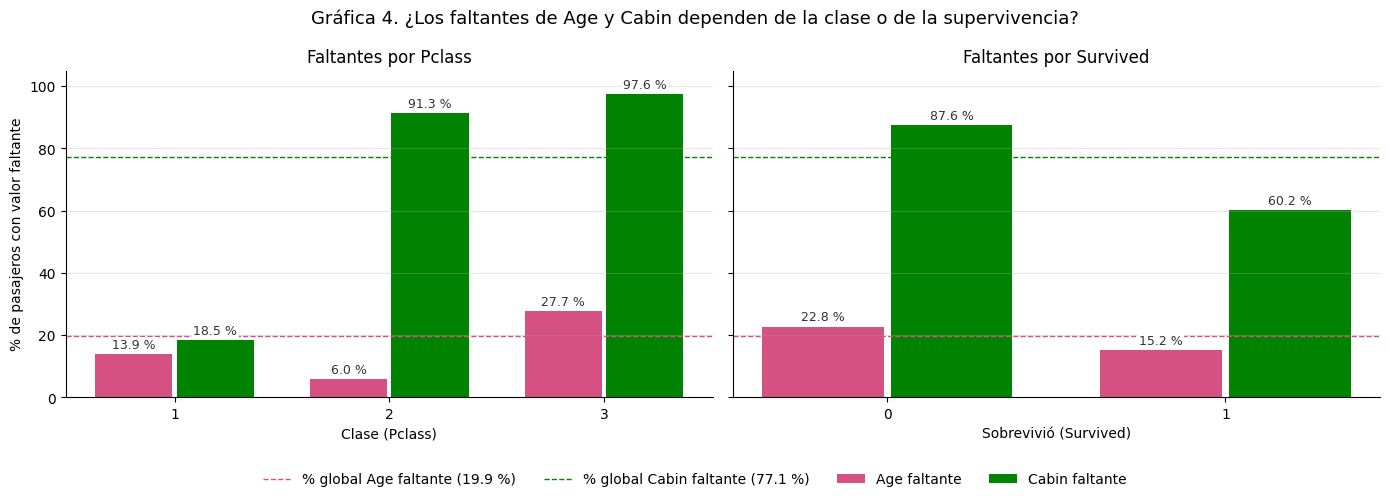

,Pasajeros,Age faltante,% Age faltante,Cabin faltante,% Cabin faltante
Grupo,,,,,
Pclass=1,216,30,13.89,40,18.52
Pclass=2,184,11,5.98,168,91.30
Pclass=3,491,136,27.70,479,97.56
Survived=0,549,125,22.77,481,87.61
Survived=1,342,52,15.20,206,60.23


In [10]:
# Gráfica 4: % de faltantes de Age y Cabin por Pclass y por Survived
COLOR_AGE_G4 = "#d55181"  # magenta
COLOR_CABIN_G4 = "#008300"  # verde
faltan = train[["Age", "Cabin"]].isna()
global_pct = faltan.mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
ancho = 0.38
for ax, grupo, etiqueta in [(axes[0], "Pclass", "Clase (Pclass)"), (axes[1], "Survived", "Sobrevivió (Survived)")]:
    pct = faltan.groupby(train[grupo]).mean() * 100
    x = np.arange(len(pct))
    for desp, col, color in [(-ancho / 2, "Age", COLOR_AGE_G4), (ancho / 2, "Cabin", COLOR_CABIN_G4)]:
        barras = ax.bar(x + desp, pct[col], width=ancho - 0.02, color=color, label=f"{col} faltante")
        ax.axhline(global_pct[col], color=color, linestyle="--", linewidth=1,
                   label=f"% global {col} faltante ({global_pct[col]:.1f} %)")
        for et in ax.bar_label(barras, labels=[f"{v:.1f} %" for v in pct[col]], padding=2, fontsize=9, color="#333333"):
            et.set_bbox(dict(facecolor="white", edgecolor="none", pad=1))
    ax.set_xticks(x, labels=[str(v) for v in pct.index])
    ax.set_xlabel(etiqueta)
    ax.set_title(f"Faltantes por {grupo}")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
axes[0].set_ylabel("% de pasajeros con valor faltante")
axes[0].set_ylim(0, 105)
manejadores, etiquetas = axes[0].get_legend_handles_labels()
fig.legend(manejadores, etiquetas, loc="lower center", ncol=4, frameon=False, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Gráfica 4. ¿Los faltantes de Age y Cabin dependen de la clase o de la supervivencia?", fontsize=13)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

# Tabla de apoyo: faltantes absolutos y relativos por grupo
tablas = []
for grupo in ["Pclass", "Survived"]:
    g = train.groupby(grupo)
    t = pd.DataFrame({
        "Pasajeros": g.size(),
        "Age faltante": g["Age"].apply(lambda s: s.isna().sum()),
        "% Age faltante": (g["Age"].apply(lambda s: s.isna().mean()) * 100).round(2),
        "Cabin faltante": g["Cabin"].apply(lambda s: s.isna().sum()),
        "% Cabin faltante": (g["Cabin"].apply(lambda s: s.isna().mean()) * 100).round(2),
    })
    t.index = [f"{grupo}={v}" for v in t.index]
    tablas.append(t)
display(pd.concat(tablas).rename_axis("Grupo"))

**Observaciones, gráfica 4: faltantes de Age y Cabin por clase y por supervivencia**

- **Los faltantes no son aleatorios: dependen de la clase.** El mecanismo no es MCAR; como mínimo es MAR respecto a `Pclass`.
- **Cabin** falta en el **18.52 %** de la 1.ª clase, contra el **91.30 %** de la 2.ª y el **97.56 %** de la 3.ª.
  - De las 204 cabinas registradas, 216 − 40 = **176 (86.27 %) son de 1.ª clase**.
  - Un derivado `TieneCabina` sería casi equivalente a `Pclass=1` y generaría reglas triviales.
  - Un derivado `Deck` solo tendría valor informativo dentro de la 1.ª clase, y su ítem `Deck=Desconocido` tendría ~77 % de soporte, otro ítem dominante.
  - *Alimenta las secciones 4 y 5:* el tratamiento de Cabin se decidirá con la prueba de asociación frente a `Pclass`. *(Resuelto en la sección 4.4: `Cabin` se descartó por actuar como sustituto de `Pclass`.)*
- **Cabin también falta más entre quienes no sobrevivieron** (**87.61 %**, contra **60.23 %** entre los sobrevivientes). Es coherente con que la clase actúe como **variable de confusión**: la 1.ª clase tiene más cabinas registradas y, como se verá en la gráfica 5, sobrevivió más.
- **Age** falta en el **27.70 %** de la 3.ª clase, el **13.89 %** de la 1.ª y solo el **5.98 %** de la 2.ª.
  - **136 de las 177 edades faltantes (76.84 %) son de 3.ª clase.**
  - También falta más entre quienes no sobrevivieron (**22.77 %**) que entre quienes sobrevivieron (**15.20 %**).
- *Alimenta la sección 4 (imputación de Age):*
  - Imputar con la **mediana global** concentraría en un solo intervalo de edad a un grupo mayoritariamente de 3.ª clase y no sobreviviente, lo que crearía asociaciones artificiales.
  - Un ítem explícito `Age=Desconocida` heredaría la asociación con `Pclass=3` y `Survived=0`. Las reglas que lo contengan reflejarían el **proceso de registro**, no el fenómeno.
  - Una imputación por grupo debe considerar la clase, además del título.

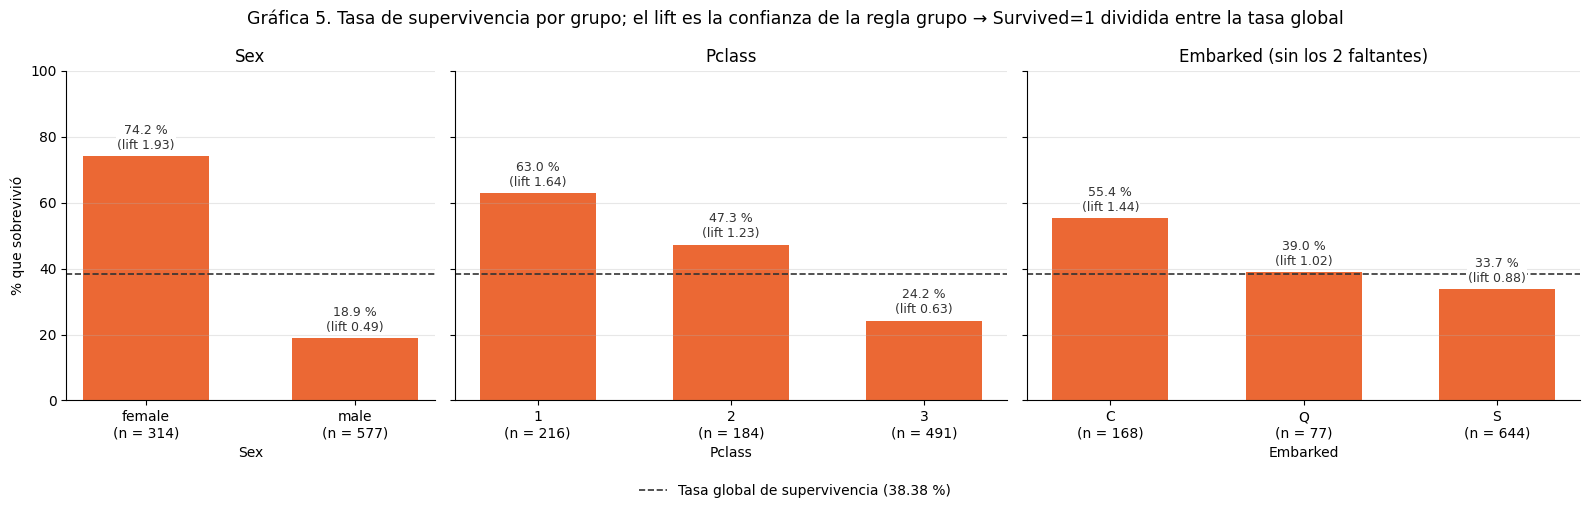

,n,Tasa de supervivencia (%),Lift (tasa / tasa global)
Grupo,,,
Sex=female,314,74.20,1.93
Sex=male,577,18.89,0.49
Pclass=1,216,62.96,1.64
Pclass=2,184,47.28,1.23
Pclass=3,491,24.24,0.63
Embarked=C,168,55.36,1.44
Embarked=Q,77,38.96,1.02
Embarked=S,644,33.70,0.88


In [11]:
# Gráfica 5: tasa de supervivencia por Sex, Pclass y Embarked, con lift respecto a la tasa global
tasa_global = train["Survived"].mean() * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True,
                         gridspec_kw={"width_ratios": [2, 3, 3]})
filas = []
for ax, col in zip(axes, ["Sex", "Pclass", "Embarked"]):
    g = train.dropna(subset=[col]).groupby(col)["Survived"].agg(["mean", "size"])
    g["tasa"] = g["mean"] * 100
    g["lift"] = g["tasa"] / tasa_global
    etiquetas_x = [f"{v}\n(n = {n})" for v, n in zip(g.index, g["size"])]
    barras = ax.bar(etiquetas_x, g["tasa"], color="#eb6834", width=0.6)
    ax.axhline(tasa_global, color="#333333", linestyle="--", linewidth=1.2,
               label=f"Tasa global de supervivencia ({tasa_global:.2f} %)")
    for et in ax.bar_label(barras, labels=[f"{t:.1f} %\n(lift {l:.2f})" for t, l in zip(g["tasa"], g["lift"])],
                           padding=3, fontsize=9, color="#333333"):
        et.set_bbox(dict(facecolor="white", edgecolor="none", pad=1))
    titulo = f"{col} (sin los {train[col].isna().sum()} faltantes)" if train[col].isna().any() else col
    ax.set_title(titulo)
    ax.set_xlabel(col)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", alpha=0.3)
    filas += [{"Grupo": f"{col}={v}", "n": int(r["size"]), "Tasa de supervivencia (%)": round(r["tasa"], 2),
               "Lift (tasa / tasa global)": round(r["lift"], 2)} for v, r in g.iterrows()]
axes[0].set_ylabel("% que sobrevivió")
axes[0].set_ylim(0, 100)
manejadores, etiquetas = axes[0].get_legend_handles_labels()
fig.legend(manejadores, etiquetas, loc="lower center", frameon=False, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Gráfica 5. Tasa de supervivencia por grupo; el lift es la confianza de la regla grupo → Survived=1 dividida entre la tasa global", fontsize=12.5)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.show()

display(pd.DataFrame(filas).set_index("Grupo"))

In [12]:
# Composición de cada puerto de embarque por clase y sexo (posible efecto de confusión en la gráfica 5)
emb = train.dropna(subset=["Embarked"])
composicion = pd.concat(
    [pd.crosstab(emb["Embarked"], emb["Pclass"], normalize="index").mul(100).add_prefix("Pclass="),
     pd.crosstab(emb["Embarked"], emb["Sex"], normalize="index").mul(100).add_prefix("Sex="),
     emb.groupby("Embarked")["Survived"].mean().mul(100).rename("Tasa de supervivencia"),
     emb["Embarked"].value_counts().rename("n")],
    axis=1,
).round(2)
display(composicion.style.format("{:.2f}", subset=composicion.columns.drop("n"))
        .set_caption("% de cada puerto por clase y sexo (filas suman 100 % dentro de cada variable)"))

,Pclass=1,Pclass=2,Pclass=3,Sex=female,Sex=male,Tasa de supervivencia,n
Embarked,,,,,,,
C,50.60,10.12,39.29,43.45,56.55,55.36,168
Q,2.60,3.90,93.51,46.75,53.25,38.96,77
S,19.72,25.47,54.81,31.52,68.48,33.70,644


**Observaciones, gráfica 5: tasa de supervivencia por grupo, y composición de los puertos**

- **La tasa global de supervivencia es 38.38 %.** El lift de cada barra es la tasa del grupo dividida entre esa tasa global; es decir, el lift de la regla `grupo → Survived=1`.
- **Sex es el factor más fuerte.**
  - `Sex=female`: **74.20 %** (n = 314), **lift 1.93**.
  - `Sex=male`: **18.89 %** (n = 577), lift 0.49.
- **Pclass muestra un gradiente monótono:** **62.96 %** en 1.ª (lift 1.64), **47.28 %** en 2.ª (lift 1.23) y **24.24 %** en 3.ª (lift 0.63). Es coherente con su lectura **ordinal** como nivel socioeconómico.
- **Embarked:** `C` tiene **55.36 %** (lift 1.44), `Q` tiene **38.96 %** (lift 1.02, prácticamente la tasa global) y `S` tiene **33.70 %** (lift 0.88).
- **La tabla de composición sugiere que el efecto del puerto es, en buena medida, de composición:**
  - De los embarcados en **C**, el **50.60 % es de 1.ª clase**, contra 19.72 % en S y 2.60 % en Q.
  - **Q** es **93.51 % de 3.ª clase**, pero tiene la mayor proporción de mujeres (**46.75 %**, contra 31.52 % en S). Esto ayuda a explicar por qué su tasa no es tan baja como la de la 3.ª clase en conjunto (24.24 %).
  - Es decir, **Pclass y Sex actúan como posibles variables de confusión** de la relación entre Embarked y Survived.
  - *Alimenta el notebook 2 (evaluación crítica):* una regla `Embarked=C → Survived=1` con lift alto no implica que embarcar en Cherbourg aumentara la supervivencia.
- **Asimetría del lift por el desbalance de Survived:** el lift máximo posible es 1 / 0.3838 ≈ **2.61** para reglas `→ Survived=1`, pero solo 1 / 0.6162 ≈ **1.62** para reglas `→ Survived=0`. *Alimenta el notebook 2:* los lifts de reglas con distinto consecuente no son directamente comparables.

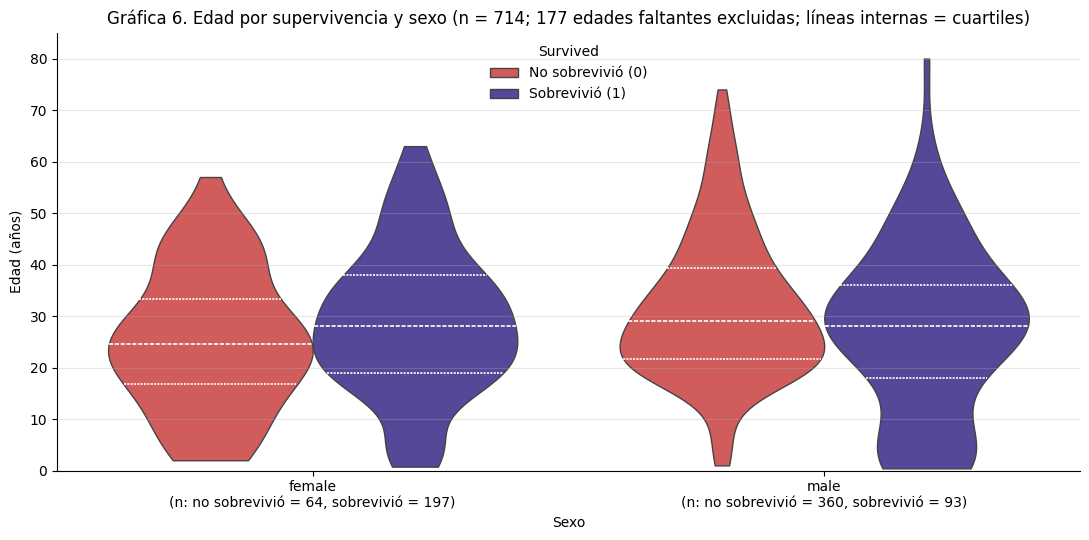

count   25%   50%   75%
Sex    Survived                         
female 0          64.0  16.8  24.5  33.2
       1         197.0  19.0  28.0  38.0
male   0         360.0  21.8  29.0  39.2
       1          93.0  18.0  28.0  36.0

Tasa de supervivencia (%)    n
Sex    Menor                                
female False                      77.18  206
       True                       69.09   55
male   False                      17.72  395
       True                       39.66   58

In [13]:
# Gráfica 6: distribución de Age por supervivencia, separada por sexo (violines con cuartiles)
con_edad = train.dropna(subset=["Age"])
paleta = {0: "#e34948", 1: "#4a3aa7"}  # rojo = no sobrevivió, violeta = sobrevivió
orden_sexo = ["female", "male"]

fig, ax = plt.subplots(figsize=(11, 5.5))
sns.violinplot(data=con_edad, x="Sex", y="Age", hue="Survived", order=orden_sexo, hue_order=[0, 1],
               split=False, inner="quart", inner_kws=dict(color="white", linewidth=1.2), cut=0, density_norm="width", palette=paleta, linewidth=1, ax=ax)

# n de cada combinación Sex × Survived en las etiquetas del eje x
n = con_edad.groupby(["Sex", "Survived"]).size()
ax.set_xticks(range(len(orden_sexo)),
              labels=[f"{s}\n(n: no sobrevivió = {n[s, 0]}, sobrevivió = {n[s, 1]})" for s in orden_sexo])
manejadores, _ = ax.get_legend_handles_labels()
ax.legend(manejadores, ["No sobrevivió (0)", "Sobrevivió (1)"], title="Survived", frameon=False, loc="upper center")
ax.set_title(f"Gráfica 6. Edad por supervivencia y sexo (n = {len(con_edad)}; "
             f"{train['Age'].isna().sum()} edades faltantes excluidas; líneas internas = cuartiles)")
ax.set_xlabel("Sexo")
ax.set_ylabel("Edad (años)")
ax.set_ylim(0, 85)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen numérico: cuartiles y tasa de supervivencia de menores de 18 por sexo
display(con_edad.groupby(["Sex", "Survived"])["Age"].describe()[["count", "25%", "50%", "75%"]].round(1))
tasa_menores = (con_edad.assign(Menor=con_edad["Age"] < 18)
                .groupby(["Sex", "Menor"])["Survived"].agg(["mean", "size"])
                .rename(columns={"mean": "Tasa de supervivencia (%)", "size": "n"}))
tasa_menores["Tasa de supervivencia (%)"] = (tasa_menores["Tasa de supervivencia (%)"] * 100).round(2)
display(tasa_menores)

**Observaciones, gráfica 6: edad por supervivencia y sexo**

- **En los hombres, la edad separa claramente.**
  - El violín de los sobrevivientes tiene un **bulto entre 0 y 10 años** que no aparece en el de los no sobrevivientes.
  - Los **varones menores de 18 sobrevivieron al 39.66 %** (n = 58), más del doble que los adultos (**17.72 %**, n = 395).
- **En las mujeres, la edad casi no separa, y si acaso en sentido contrario.**
  - Las menores de 18 sobrevivieron al **69.09 %** (n = 55), contra el **77.18 %** de las adultas (n = 206).
  - La mediana de edad de las no sobrevivientes (**24.5**) es menor que la de las sobrevivientes (**28.0**).
- **Entre los 20 y los 40 años, las distribuciones de los cuatro grupos se parecen mucho.** Las medianas están entre **24.5 y 29.0**, y en tres de los cuatro grupos entre 28 y 29.
- **Hay una interacción Sex × Age:** el efecto de ser menor depende del sexo.
  - La asociación informativa es `{Sex=male, Age=menor} → Survived=1`, no `Age=menor → Survived=1` por sí sola.
  - Ese itemset es pequeño: los varones menores de 18 con edad registrada son 58, el **6.51 %** de 891.
  - *Alimenta la sección 6 y el notebook 2:* los cortes de Age deben aislar a los niños pequeños, y un soporte mínimo alto podría dejar fuera esta regla.
- Los violines están normalizados por ancho (`density_norm="width"`), así que no comparan tamaños de grupo. Para eso están los n del eje x.

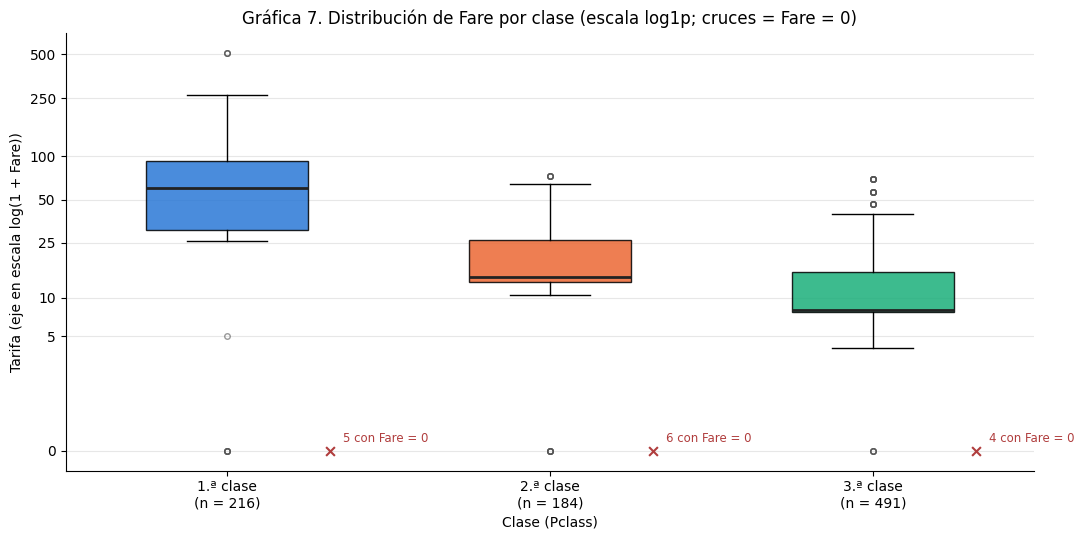

,count,min,25%,50%,75%,max
Pclass,,,,,,
1,216.0,0.0,30.92,60.29,93.5,512.33
2,184.0,0.0,13.00,14.25,26.0,73.50
3,491.0,0.0,7.75,8.05,15.5,69.55


Pclass,1,2,3
Cuartil global de Fare,,,
"(-0.001, 7.91]",2.69,2.69,94.62
"(7.91, 14.454]",0.00,38.39,61.61
"(14.454, 31.0]",22.97,31.53,45.50
"(31.0, 512.329]",71.62,9.91,18.47


In [14]:
# Gráfica 7: Fare por Pclass en escala log1p (redundancia entre tarifa y clase)
COLOR_CLASE = {1: "#2a78d6", 2: "#eb6834", 3: "#1baf7a"}  # paleta categórica validada (CVD), fija por clase
clases = [1, 2, 3]

fig, ax = plt.subplots(figsize=(11, 5.5))
datos = [np.log1p(train.loc[train["Pclass"] == c, "Fare"]) for c in clases]
cajas = ax.boxplot(datos, positions=clases, widths=0.5, patch_artist=True, whis=1.5,
                   medianprops=dict(color="#222222", linewidth=2),
                   flierprops=dict(marker="o", markersize=4, markerfacecolor="none", markeredgecolor="#555555", alpha=0.6))
for caja, c in zip(cajas["boxes"], clases):
    caja.set_facecolor(COLOR_CLASE[c])
    caja.set_alpha(0.85)

# Fare = 0 marcados aparte (cruces rojas en y = 0)
ceros = train[train["Fare"] == 0]
for c in clases:
    k = (ceros["Pclass"] == c).sum()
    if k:
        ax.scatter([c + 0.32], [0], marker="x", color="#B03D3D", s=40, zorder=3)
        ax.annotate(f"{k} con Fare = 0", (c + 0.36, 0), xytext=(0, 4), textcoords="offset points",
                    fontsize=8.5, color="#B03D3D", va="bottom")

marcas = [0, 5, 10, 25, 50, 100, 250, 500]
ax.set_yticks(np.log1p(marcas), labels=marcas)
ax.set_xticks(clases, labels=[f"{c}.ª clase\n(n = {(train['Pclass'] == c).sum()})" for c in clases])
ax.set_xlabel("Clase (Pclass)")
ax.set_ylabel("Tarifa (eje en escala log(1 + Fare))")
ax.set_title("Gráfica 7. Distribución de Fare por clase (escala log1p; cruces = Fare = 0)")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Resumen por clase: cuartiles de Fare
display(train.groupby("Pclass")["Fare"].describe()[["count", "min", "25%", "50%", "75%", "max"]].round(2))

# Traslape: cómo se reparten los cuartiles globales de Fare entre las clases (% de cada cuartil)
cuartil_fare = pd.qcut(train["Fare"], 4)
display(pd.crosstab(cuartil_fare, train["Pclass"], normalize="index").mul(100).round(2)
        .rename_axis(index="Cuartil global de Fare", columns="Pclass"))

**Observaciones, gráfica 7: Fare por clase**

- **Las medianas de Fare siguen el orden de la clase:** **60.29** en 1.ª, **14.25** en 2.ª y **8.05** en 3.ª. Esto es coherente con leer `Pclass` como variable **ordinal** de nivel socioeconómico, como indica el diccionario de datos.
- **La 1.ª clase se separa casi por completo:** su IQR va de **30.92** a **93.50**. Los máximos de 2.ª y 3.ª son **73.50** y **69.55**.
- **La 2.ª y la 3.ª se traslapan:** el IQR de 2.ª va de **13.00** a **26.00** y el de 3.ª de **7.75** a **15.50**.
- **Fare = 0 aparece en las tres clases** (5, 6 y 4 pasajeros). Si no se tratan, esos pasajeros de 1.ª y 2.ª caerían en el intervalo más bajo de tarifa.
- **Redundancia con los cuartiles globales de Fare** (la tabla cruzada muestra el % de cada cuartil por clase):
  - El cuartil más bajo (≤ 7.91) es **94.62 % de 3.ª clase**, y el más alto (> 31.0) es **71.62 % de 1.ª clase**.
  - El segundo cuartil (7.91–14.45) **no contiene ningún pasajero de 1.ª clase (0.00 %)**.
  - Si Fare se discretiza por cuartiles, aparecerán reglas casi tautológicas como `Fare=cuartil_bajo → Pclass=3`, con confianza cercana al 95 %.
  - Los cuartiles intermedios sí mezclan clases. En el tercero (14.45–31.0) hay 22.97 % de 1.ª, 31.53 % de 2.ª y 45.50 % de 3.ª, así que ahí Fare aporta información que la clase no da.
- *Alimenta las secciones 5 y 6:* medir la asociación entre Fare discretizada y `Pclass`, y decidir si se conservan ambas (filtrando las reglas triviales) o se reduce una.
- Nota técnica: en esta gráfica los bigotes y los puntos aislados se calculan **sobre la escala log1p y dentro de cada clase**. Por eso no coinciden con los outliers IQR de la gráfica 2, que se calcularon sobre Fare original y sobre todos los pasajeros.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">CALIDAD · REPORTE</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">3. Reporte por dimensiones de calidad</span></div>

Se organizan los hallazgos del perfilado según **dimensiones de calidad de datos**. Antes de construir el reporte se hacen dos chequeos adicionales que el perfilado dejó abiertos:

- **Consistencia entre `Ticket` y `Fare`:** ¿los pasajeros que comparten boleto tienen la misma tarifa?
- **Precisión del formato de `Ticket`:** ¿hay prefijos escritos de varias formas?

In [15]:
# Chequeo de consistencia: ¿los pasajeros que comparten Ticket tienen el mismo Fare?
tam_grupo = train.groupby("Ticket")["PassengerId"].transform("size")
compartidos = train[tam_grupo > 1]
por_boleto = compartidos.groupby("Ticket").agg(Pasajeros=("PassengerId", "size"),
                                                Fares_distintos=("Fare", "nunique"),
                                                Clases_distintas=("Pclass", "nunique"))
print(f"Boletos compartidos: {len(por_boleto)} ({len(compartidos)} pasajeros)")
print(f"Boletos con un único Fare: {(por_boleto['Fares_distintos'] == 1).sum()} "
      f"({(por_boleto['Fares_distintos'] == 1).mean() * 100:.2f} %)")
print(f"Boletos compartidos con más de una clase: {(por_boleto['Clases_distintas'] > 1).sum()}")
excepciones = por_boleto.index[por_boleto["Fares_distintos"] > 1]
display(train[train["Ticket"].isin(excepciones)][["PassengerId", "Ticket", "Pclass", "Fare", "Name"]])

# Si Fare es el total del boleto, debería crecer con el tamaño del grupo y Fare / tamaño debería ser estable
fare_grupo = train.assign(Tamaño=tam_grupo, Fare_por_persona=train["Fare"] / tam_grupo)
medianas = (fare_grupo.groupby(["Tamaño", "Pclass"])[["Fare", "Fare_por_persona"]].median()
            .unstack("Pclass").round(2))
display(medianas.style.format("{:.2f}", na_rep="—")
        .set_caption("Mediana de Fare y de Fare / tamaño de grupo, por tamaño de grupo y clase (solo train)"))

cv = fare_grupo.groupby("Pclass")[["Fare", "Fare_por_persona"]].agg(lambda s: s.std() / s.mean()).round(2)
display(cv.rename(columns={"Fare": "CV de Fare", "Fare_por_persona": "CV de Fare / tamaño"})
        .rename_axis("Pclass"))

Boletos compartidos: 134 (344 pasajeros)
Boletos con un único Fare: 133 (99.25 %)
Boletos compartidos con más de una clase: 0


,PassengerId,Ticket,Pclass,Fare,Name
138,139,7534,3,9.2167,"Osen, Mr. Olaf Elon"
876,877,7534,3,9.8458,"Gustafsson, Mr. Alfred Ossian"


,CV de Fare,CV de Fare / tamaño
Pclass,,
1,0.93,0.69
2,0.65,0.42
3,0.86,0.30


In [16]:
# Chequeo de precisión: variantes de escritura en los prefijos de Ticket
partes = train["Ticket"].str.extract(r"^(?:(?P<prefijo>.+)\s+)?(?P<numero>\d+)$")
print(f"Solo número: {(partes['prefijo'].isna() & partes['numero'].notna()).sum()} | "
      f"prefijo + número: {partes['prefijo'].notna().sum()} | "
      f"sin número: {partes['numero'].isna().sum()} -> {train.loc[partes['numero'].isna(), 'Ticket'].unique().tolist()}")

# Normalización: mayúsculas y sin puntos, barras ni espacios
partes["prefijo_norm"] = partes["prefijo"].str.upper().str.replace(r"[.\s/]", "", regex=True)
print(f"Prefijos distintos tal como están escritos: {partes['prefijo'].nunique()} | "
      f"tras normalizar: {partes['prefijo_norm'].nunique()}")

# Forma canónica: la variante más frecuente; en empate, la primera en orden alfabético
filas = []
for norm, grupo in partes.dropna(subset=["prefijo"]).groupby("prefijo_norm"):
    frec = grupo["prefijo"].value_counts()
    if len(frec) > 1:
        canonica = sorted(frec[frec == frec.max()].index)[0]
        filas.append({"Prefijo normalizado": norm, "Forma canónica": canonica,
                      "Variantes (frecuencia)": ", ".join(f"{v} ({n})" for v, n in frec.items()),
                      "Pasajeros": int(frec.sum()), "No canónicos": int(frec.sum() - frec[canonica])})
variantes = pd.DataFrame(filas).sort_values("Pasajeros", ascending=False).set_index("Prefijo normalizado")
display(variantes)
no_canonicos = variantes["No canónicos"].sum()
print(f"Tickets escritos en una variante no canónica: {no_canonicos} = "
      f"{no_canonicos / len(train) * 100:.2f} % de {len(train)} pasajeros | "
      f"{no_canonicos / partes['prefijo'].notna().sum() * 100:.2f} % de {partes['prefijo'].notna().sum()} tickets con prefijo")

# Números de boleto que aparecen con prefijos distintos (o con y sin prefijo)
formas = partes.dropna(subset=["numero"]).assign(Ticket=train["Ticket"]).groupby("numero")["Ticket"].unique()
repetidos = formas[formas.apply(len) > 1]
print(f"Números de boleto escritos con prefijos distintos: {len(repetidos)}")
display(train[partes["numero"].isin(repetidos.index)]
        .assign(Número=partes["numero"])[["Número", "PassengerId", "Ticket", "Pclass", "Fare", "Name"]]
        .sort_values(["Número", "Ticket"]))

# ¿Cómo cambian los grupos según la clave usada para agrupar?
ticket_norm = partes["prefijo_norm"].fillna("") + " " + partes["numero"].fillna(train["Ticket"])
solo_numero = partes["numero"].fillna(train["Ticket"])
display(pd.DataFrame({
    "Clave de agrupación": ["Ticket tal cual", "Ticket con prefijo normalizado", "Solo el número"],
    "Boletos distintos": [train["Ticket"].nunique(), ticket_norm.nunique(), solo_numero.nunique()],
    "Pasajeros que comparten boleto": [(train.groupby(k)["PassengerId"].transform("size") > 1).sum()
                                        for k in [train["Ticket"], ticket_norm, solo_numero]],
}).set_index("Clave de agrupación"))

Solo número: 661 | prefijo + número: 226 | sin número: 4 -> ['LINE']
Prefijos distintos tal como están escritos: 43 | tras normalizar: 28


,Forma canónica,Variantes (frecuencia),Pasajeros,No canónicos
Prefijo normalizado,,,,
CA,C.A.,"C.A. (27), CA. (8), CA (6)",41,14
A5,A/5,"A/5 (10), A/5. (7), A./5. (2), A.5. (2)",21,11
STONO2,STON/O 2.,"STON/O 2. (12), STON/O2. (6)",18,6
SOTONOQ,SOTON/O.Q.,"SOTON/O.Q. (8), SOTON/OQ (7)",15,7
SCPARIS,SC/PARIS,"SC/PARIS (5), SC/Paris (4), S.C./PARIS (2)",11,6
WC,W./C.,"W./C. (9), W/C (1)",10,1
A4,A/4,"A/4. (3), A/4 (3), A4. (1)",7,4
SOC,S.O.C.,"S.O.C. (5), SO/C (1)",6,1
WEP,WE/P,"WE/P (2), W.E.P. (1)",3,1


Tickets escritos en una variante no canónica: 52 = 5.84 % de 891 pasajeros | 23.01 % de 226 tickets con prefijo
Números de boleto escritos con prefijos distintos: 2


,Número,PassengerId,Ticket,Pclass,Fare,Name
690,17474,691,17474,1,57.0000,"Dick, Mr. Albert Adrian"
781,17474,782,17474,1,57.0000,"Dick, Mrs. Albert Adrian (Vera Gillespie)"
572,17474,573,PC 17474,1,26.3875,"Flynn, Mr. John Irwin (""Irving"")"
648,751,649,S.O./P.P. 751,3,7.5500,"Willey, Mr. Edward"
226,751,227,SW/PP 751,2,10.5000,"Mellors, Mr. William John"


,Boletos distintos,Pasajeros que comparten boleto
Clave de agrupación,,
Ticket tal cual,681,344
Ticket con prefijo normalizado,681,344
Solo el número,679,347


**Observaciones: chequeos de Ticket–Fare y de prefijos de Ticket**

*Consistencia entre Ticket y Fare*
- **133 de 134 boletos compartidos (99.25 %) tienen un único valor de Fare** para todos sus pasajeros.
  - La única excepción es el ticket `7534`, con dos pasajeros de 3.ª clase que pagan **9.2167** y **9.8458**. Es una diferencia pequeña; podrían ser dos compras con el mismo número.
  - **Ningún boleto compartido mezcla clases.**
- **Fare crece con el tamaño del grupo, mientras que Fare / tamaño se mantiene casi constante dentro de cada clase.**
  - En 3.ª clase, la mediana de Fare pasa de **7.90** (1 pasajero) a **56.50** (7 pasajeros), pero la mediana por persona se mantiene entre **5.82 y 8.07**.
  - La dispersión relativa (CV) baja de **0.93 → 0.69** en 1.ª, de **0.65 → 0.42** en 2.ª y de **0.86 → 0.30** en 3.ª al dividir entre el tamaño del grupo.
- **Verificación externa:** fuera de este notebook se comprobó que los **152** pasajeros de `test.csv` que comparten ticket con alguno de `train` tienen **exactamente el mismo Fare** (152/152). `test.csv` no entra al análisis; solo se usó para confirmar.
- **Conclusión:** `Fare` es el **precio total del boleto**, no el precio por persona. Una tarifa alta en 3.ª clase suele indicar un grupo grande, no un boleto caro.
- *Alimenta la sección 6 (binning de Fare):* usar Fare tal cual o una tarifa por persona. *(Resuelto: se usa `Fare` tal cual, discretizado en cuartiles; la tarifa por persona requeriría contar grupos por Ticket, que se descartó en la sección 4.3.)*

*Precisión del formato de Ticket*
- **Estructura:** 661 tickets son solo número, 226 tienen prefijo + número, y 4 son el texto `LINE` sin número.
- **Hay 43 prefijos tal como están escritos, que se reducen a 28 al normalizar** (mayúsculas, sin puntos, barras ni espacios).
  - **10 prefijos aparecen escritos de más de una forma.** Por ejemplo, `C.A.` / `CA.` / `CA`, y `A/5` / `A/5.` / `A./5.` / `A.5.`.
- **Forma canónica:** la variante **más frecuente** de cada prefijo; en caso de empate, la primera en orden alfabético. El único empate es `A/4.` frente a `A/4` (3 cada una), y se toma `A/4`.
- **% de datos incorrectos: 52 tickets en una variante no canónica, el 5.84 % de los 891 pasajeros** (el 23.01 % de los 226 tickets con prefijo).
  - Es un problema de **formato**, no de datos falsos: el emisor del boleto es el mismo, escrito de distintas formas.
- **Hay 2 números de boleto que aparecen con prefijos distintos:**
  - `17474` (los Dick, 1.ª clase, Fare 57.00) frente a `PC 17474` (Flynn, 1.ª clase, Fare 26.39);
  - `SW/PP 751` (Mellors, 2.ª clase, Fare 10.50) frente a `S.O./P.P. 751` (Willey, 3.ª clase, Fare 7.55).

  En ambos casos difieren la tarifa o la clase, así que lo más probable es que sean **boletos distintos** cuyos números coinciden.
- **Efecto en el conteo de grupos:**
  - Agrupar por el Ticket tal cual o con el prefijo normalizado da **los mismos grupos** (681 boletos; 344 pasajeros comparten). Fuera del notebook se verificó que lo mismo ocurre al contar con `train` + `test`.
  - En cambio, **agrupar solo por el número une por error esos 2 casos** (679 boletos; 347 pasajeros "comparten").
- **Decisión pendiente para la sección 4:** elegir la clave para contar grupos, el Ticket tal cual o con el prefijo normalizado (hoy equivalentes). En ningún caso se usará solo el número.

In [17]:
# Reporte de calidad por dimensiones
# --- Validez: verificación explícita de dominios según el diccionario de datos ---
dominios = {
    "Survived ∈ {0, 1}":           ~train["Survived"].isin([0, 1]),
    "Pclass ∈ {1, 2, 3}":          ~train["Pclass"].isin([1, 2, 3]),
    "Sex ∈ {female, male}":        ~train["Sex"].isin(["female", "male"]),
    "Embarked ∈ {C, Q, S} o nulo": ~(train["Embarked"].isin(["C", "Q", "S"]) | train["Embarked"].isna()),
    "0 < Age ≤ 100 o nulo":        ~(train["Age"].between(0, 100, inclusive="right") | train["Age"].isna()),
    "SibSp entero ≥ 0":            ~((train["SibSp"] >= 0) & (train["SibSp"] % 1 == 0)),
    "Parch entero ≥ 0":            ~((train["Parch"] >= 0) & (train["Parch"] % 1 == 0)),
    "Fare ≥ 0":                    ~(train["Fare"] >= 0),
}
validez = pd.Series({regla: int(viola.sum()) for regla, viola in dominios.items()}, name="Registros que violan la regla")
display(validez.rename_axis("Regla de dominio").to_frame())

# --- Cifras de apoyo calculadas a partir de los datos ---
nulos = train.isna().sum()
edad = train["Age"].dropna()
n_estimadas = int(((edad % 1) == 0.5).sum())
n_fare0 = int((train["Fare"] == 0).sum())
n_out = int(es_out_sup.sum())
pct_out_1a = es_out_sup[train["Pclass"] == 1].sum() / es_out_sup.sum() * 100
n_menores_p0 = int(((train["Age"] < 18) & (train["Parch"] == 0)).sum())
n_menores = int((train["Age"] < 18).sum())
fare_bajo_1a = train[(train["Pclass"] == 1) & (train["Fare"] > 0) & (train["Fare"] < 20)]
pct_mismo_fare = (por_boleto["Fares_distintos"] == 1).mean() * 100
cabinas_multiples = int(train["Cabin"].str.count(r"[A-Z]\d+").ge(2).sum())  # p. ej. "C23 C25 C27"
cabinas_letra = int(train["Cabin"].str.match(r"^[A-Z] [A-Z]\d+$", na=False).sum())  # p. ej. "F G73"
n_con_prefijo = int(partes["prefijo"].notna().sum())


reporte = pd.DataFrame([
    ["Exactitud", "Los datos reflejan la realidad sin errores.",
     "Edades estimadas (xx.5); Fare = 0; outliers de Fare (máx. 512.33). Verificado: Fare = 0 refleja boletos sin costo "
     "(patrones LINE y boletos consecutivos) y los outliers son plausibles (sobre todo 1.ª clase), no errores.",
     f"{n_estimadas} edades xx.5 ({n_estimadas / len(edad) * 100:.2f} % de las registradas); {n_fare0} con Fare = 0; "
     f"{n_out} outliers IQR, {pct_out_1a:.2f} % de 1.ª clase (sección 2, gráfica 2)", "Parcial"],
    ["Completitud", "No hay datos faltantes o vacíos.",
     "Faltan valores en Age, Cabin y Embarked; los faltantes de Age y Cabin dependen de la clase.",
     f"Age {nulos['Age']} ({nulos['Age'] / len(train) * 100:.2f} %), Cabin {nulos['Cabin']} "
     f"({nulos['Cabin'] / len(train) * 100:.2f} %), Embarked {nulos['Embarked']} "
     f"({nulos['Embarked'] / len(train) * 100:.2f} %) (sección 2, gráfica 4)", "Sí"],
    ["Consistencia", "Los datos mantienen coherencia a lo largo del sistema.",
     "Menores con Parch = 0: consistente con el diccionario (algunos viajaban con niñera). Pasajero de 1.ª clase con "
     "Fare = 5.00: inconsistencia aparente entre Pclass y Fare. Ticket–Fare: quienes comparten boleto comparten tarifa, "
     "así que Fare es el total del boleto.",
     f"{n_menores_p0} de {n_menores} menores con Parch = 0; PassengerId {fare_bajo_1a['PassengerId'].tolist()} con Fare "
     f"{fare_bajo_1a['Fare'].tolist()}; {pct_mismo_fare:.2f} % de boletos compartidos con un único Fare (sección 3)", "Parcial"],
    ["Validez", "Cumplen con las reglas y formatos esperados.",
     "Se verificaron explícitamente los dominios del diccionario: valores categóricos dentro de su conjunto y rangos "
     "numéricos válidos.",
     f"{int(validez.sum())} violaciones en {len(validez)} reglas de dominio (tabla anterior)",
     "Sí" if validez.sum() else "No"],
    ["Accesibilidad", "Disponibilidad fácil para los usuarios autorizados.",
     "Dataset público en Kaggle, descargable con una cuenta gratuita.", "Enlace en la celda de presentación", "No"],
    ["Trazabilidad", "Se puede rastrear el origen y transformaciones de los datos.",
     "Kaggle no documenta el origen de cada registro, así que no es evaluable registro por registro. La trazabilidad de "
     "nuestras transformaciones la garantizan este notebook y la bitácora de la sección 8.",
     "Ausencia de metadatos de origen por registro", "No evaluable"],
    ["Relevancia", "La información obtenida a partir de los datos disponibles debe ser útil y aplicable a la situación.",
     "PassengerId, Name y Ticket no son útiles como ítems (identificadores o casi únicos); de Name y Ticket pueden "
     "derivarse atributos útiles (Title, tamaño de grupo).",
     f"Valores únicos: PassengerId {train['PassengerId'].nunique()}, Name {train['Name'].nunique()}, "
     f"Ticket {train['Ticket'].nunique()} de {len(train)} (sección 2)", "Parcial"],
    ["Oportunidad", "La información debe estar disponible en el momento adecuado.",
     "Datos históricos (1912) y estáticos; no hay actualización que evaluar.", "—", "No evaluable"],
    ["Interpretabilidad", "La información debe ser comprensible y utilizable por los usuarios.",
     "Formatos mixtos en Ticket (con y sin prefijo, texto LINE) y en Cabin (varias cabinas en un campo, o una letra suelta antes de la cabina, como «F G73»); "
     "códigos que requieren el diccionario (Survived 0/1, Pclass 1/2/3, Embarked C/Q/S, SibSp, Parch).",
     f"{partes['prefijo'].nunique()} prefijos de Ticket; {cabinas_multiples} valores de Cabin con varias cabinas y "
     f"{cabinas_letra} con formato «letra + cabina»", "Parcial"],
    ["Precisión", "Se verifica comparando con fuentes confiables, buscando contradicciones y "
     "detectando valores atípicos o errores numéricos. Métrica: % de datos incorrectos.",
     "Prefijos de Ticket escritos de varias formas (p. ej. C.A. / CA. / CA). Forma canónica = variante más frecuente "
     "(empate: orden alfabético). Problema de formato, no de datos falsos; Ticket no será ítem. "
     "Nota secundaria: Fare con hasta 4 decimales, más detalle del necesario (el binning lo reduce).",
     f"{no_canonicos} tickets no canónicos = {no_canonicos / len(train) * 100:.2f} % de {len(train)} "
     f"({no_canonicos / n_con_prefijo * 100:.2f} % de {n_con_prefijo} con prefijo) (sección 3)", "Parcial"],
    ["Fiabilidad", "Las fuentes son confiables, legítimas y verificables, y el proceso de captura es correcto.",
     "Fuente secundaria (Kaggle); el proceso de captura original no está documentado en el dataset.", "—", "No evaluable"],
    ["Unicidad", "Cada registro en un conjunto de datos representa una entidad única y no está repetido.",
     "Sin registros duplicados. Los boletos compartidos no son duplicados: son pasajeros distintos con el mismo Ticket.",
     f"{train['PassengerId'].duplicated().sum()} PassengerId y {train['Name'].duplicated().sum()} Name duplicados; "
     f"{(tam_grupo > 1).sum()} pasajeros comparten boleto (sección 2)", "No"],
], columns=["Dimensión", "Definición", "Hallazgo en Titanic", "Evidencia", "¿Problema?"])

COLOR_PROBLEMA = {"Sí": "#F6D3D3", "Parcial": "#FBE7C2", "No": "#D6EDDA", "No evaluable": "#E6E6E6"}
display(reporte.style.hide(axis="index")
        .map(lambda v: f"background-color: {COLOR_PROBLEMA.get(v, '')}; font-weight: 600", subset=["¿Problema?"])
        .set_properties(**{"text-align": "left", "white-space": "normal", "vertical-align": "top"})
        .set_caption("Reporte de calidad de train por dimensiones"))
print(reporte["¿Problema?"].value_counts().to_string())

,Registros que violan la regla
Regla de dominio,
"Survived ∈ {0, 1}",0
"Pclass ∈ {1, 2, 3}",0
"Sex ∈ {female, male}",0
"Embarked ∈ {C, Q, S} o nulo",0
0 < Age ≤ 100 o nulo,0
SibSp entero ≥ 0,0
Parch entero ≥ 0,0
Fare ≥ 0,0


Dimensión,Definición,Hallazgo en Titanic,Evidencia,¿Problema?
Exactitud,Los datos reflejan la realidad sin errores.,"Edades estimadas (xx.5); Fare = 0; outliers de Fare (máx. 512.33). Verificado: Fare = 0 refleja boletos sin costo (patrones LINE y boletos consecutivos) y los outliers son plausibles (sobre todo 1.ª clase), no errores.","18 edades xx.5 (2.52 % de las registradas); 15 con Fare = 0; 116 outliers IQR, 89.66 % de 1.ª clase (sección 2, gráfica 2)",Parcial
Completitud,No hay datos faltantes o vacíos.,"Faltan valores en Age, Cabin y Embarked; los faltantes de Age y Cabin dependen de la clase.","Age 177 (19.87 %), Cabin 687 (77.10 %), Embarked 2 (0.22 %) (sección 2, gráfica 4)",Sí
Consistencia,Los datos mantienen coherencia a lo largo del sistema.,"Menores con Parch = 0: consistente con el diccionario (algunos viajaban con niñera). Pasajero de 1.ª clase con Fare = 5.00: inconsistencia aparente entre Pclass y Fare. Ticket–Fare: quienes comparten boleto comparten tarifa, así que Fare es el total del boleto.",32 de 113 menores con Parch = 0; PassengerId [873] con Fare [5.0]; 99.25 % de boletos compartidos con un único Fare (sección 3),Parcial
Validez,Cumplen con las reglas y formatos esperados.,Se verificaron explícitamente los dominios del diccionario: valores categóricos dentro de su conjunto y rangos numéricos válidos.,0 violaciones en 8 reglas de dominio (tabla anterior),No
Accesibilidad,Disponibilidad fácil para los usuarios autorizados.,"Dataset público en Kaggle, descargable con una cuenta gratuita.",Enlace en la celda de presentación,No
Trazabilidad,Se puede rastrear el origen y transformaciones de los datos.,"Kaggle no documenta el origen de cada registro, así que no es evaluable registro por registro. La trazabilidad de nuestras transformaciones la garantizan este notebook y la bitácora de la sección 8.",Ausencia de metadatos de origen por registro,No evaluable
Relevancia,La información obtenida a partir de los datos disponibles debe ser útil y aplicable a la situación.,"PassengerId, Name y Ticket no son útiles como ítems (identificadores o casi únicos); de Name y Ticket pueden derivarse atributos útiles (Title, tamaño de grupo).","Valores únicos: PassengerId 891, Name 891, Ticket 681 de 891 (sección 2)",Parcial
Oportunidad,La información debe estar disponible en el momento adecuado.,Datos históricos (1912) y estáticos; no hay actualización que evaluar.,—,No evaluable
Interpretabilidad,La información debe ser comprensible y utilizable por los usuarios.,"Formatos mixtos en Ticket (con y sin prefijo, texto LINE) y en Cabin (varias cabinas en un campo, o una letra suelta antes de la cabina, como «F G73»); códigos que requieren el diccionario (Survived 0/1, Pclass 1/2/3, Embarked C/Q/S, SibSp, Parch).",43 prefijos de Ticket; 20 valores de Cabin con varias cabinas y 4 con formato «letra + cabina»,Parcial
Precisión,"Se verifica comparando con fuentes confiables, buscando contradicciones y detectando valores atípicos o errores numéricos. Métrica: % de datos incorrectos.","Prefijos de Ticket escritos de varias formas (p. ej. C.A. / CA. / CA). Forma canónica = variante más frecuente (empate: orden alfabético). Problema de formato, no de datos falsos; Ticket no será ítem. Nota secundaria: Fare con hasta 4 decimales, más detalle del necesario (el binning lo reduce).",52 tickets no canónicos = 5.84 % de 891 (23.01 % de 226 con prefijo) (sección 3),Parcial


¿Problema?
Parcial         5
No              3
No evaluable    3
Sí              1


**Observaciones: reporte de calidad**

- **Resumen de las 12 dimensiones:** **1 con problema (Sí)**, **5 parciales**, **3 sin problema (No)** y **3 no evaluables**.
- **El único problema pleno es la Completitud.**
  - Faltan **177 edades (19.87 %)**, **687 cabinas (77.10 %)** y **2 puertos de embarque (0.22 %)**.
  - Además, los faltantes de Age y Cabin **dependen de la clase** (gráfica 4).
  - Es la dimensión que más decisiones exige en la limpieza.
- **Validez sin problemas:** las **8 reglas de dominio** del diccionario se cumplen, con **0 violaciones**.
- **Unicidad sin problemas:** **0 registros duplicados**. Los **344 pasajeros** que comparten boleto son personas distintas, no repeticiones.
- **Los 5 parciales son de dos tipos:**
  - **Requieren una decisión posterior:**
    - **Consistencia:** `Fare` es el total del boleto (**99.25 %** de los boletos compartidos tienen un único Fare), lo que afecta al binning de Fare (sección 6). Además, el pasajero **873** de 1.ª clase con Fare **5.00** se trata en la sección 4.
    - **Relevancia:** `PassengerId`, `Name` y `Ticket` no sirven como ítems, pero de `Name` y `Ticket` pueden derivarse Title y tamaño de grupo (sección 6). *(Resuelto: `Title` se derivó en la sección 4.5 y se usó solo para imputar `Age`; el tamaño de grupo salió de `FamilySize`.)*
  - **Solo se documentan:**
    - **Exactitud:** se verificó que Fare = 0 refleja boletos sin costo y que los **116** outliers de Fare son plausibles. Las **18** edades estimadas (xx.5) tienen un efecto despreciable tras el binning.
    - **Interpretabilidad:** formatos mixtos de Ticket y Cabin, y códigos que requieren el diccionario.
    - **Precisión:** **52** tickets (**5.84 %**) escritos en una variante no canónica. Es un problema de formato, y Ticket no será ítem.
- **Los no evaluables** (Trazabilidad, Oportunidad y Fiabilidad) se deben a que el dataset es una fuente secundaria, histórica y estática. La trazabilidad de *nuestras* transformaciones queda cubierta por este notebook y por la bitácora de la sección 8.

**Decisiones pendientes que pasan a la sección 4 (limpieza)**

1. **Age:** cómo tratar las **177** edades faltantes, que se concentran en 3.ª clase.
2. **Cabin:** descartarla o derivar un atributo, con **77.10 %** de faltantes y fuerte dependencia de la clase.
3. **Embarked:** qué hacer con los **2** valores faltantes.
4. **Fare = 0:** cómo tratar a los **15** pasajeros con boleto sin costo, repartidos en las tres clases.
5. **Pasajero 873:** 1.ª clase con Fare **5.00**, una inconsistencia aparente.
6. **Clave para contar grupos por Ticket:** el Ticket tal cual o con el prefijo normalizado (hoy equivalentes), nunca solo el número.

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">CALIDAD · LIMPIEZA</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">4. Limpieza e imputación</span></div>

Se resuelven, una por una, las decisiones pendientes del reporte de calidad. Cada decisión se toma pensando en las **reglas de asociación**: una imputación no solo rellena un hueco, también puede crear ítems y asociaciones artificiales. Las modificaciones se hacen sobre una copia de trabajo (`limpio`), de modo que `train` queda intacto como referencia. Cada cambio se registra en la **bitácora de calidad**, que se presenta completa en la sección 8.

#### 4.1 Embarked: 2 valores faltantes

In [18]:
# Copia de trabajo, bitácora de calidad e imputación de Embarked
limpio = train.copy()
bitacora = []


def registrar(hallazgo, deteccion, evidencia, accion):
    """
    Agrega una entrada a la bitácora de calidad.

    Parámetros
    ----------
    hallazgo : str
        Problema de calidad encontrado.
    deteccion : str
        Cómo y dónde se detectó (sección, método).
    evidencia : str
        Cifras que lo respaldan.
    accion : str
        Qué se hizo, incluyendo cuántas filas se modificaron.

    Retorna
    -------
    None
        La entrada se agrega a la lista global `bitacora`.
    """
    bitacora.append({"Hallazgo": hallazgo, "Detección": deteccion, "Evidencia": evidencia, "Acción": accion})


# Las dos pasajeras sin Embarked
falta_emb = limpio["Embarked"].isna()
display(limpio.loc[falta_emb, ["PassengerId", "Name", "Pclass", "Sex", "Age", "Ticket", "Fare", "Cabin", "Survived"]])

# Pista por tarifa: Fare por persona (Fare / pasajeros del boleto) en 1.ª clase según el puerto
tam_boleto = limpio.groupby("Ticket")["PassengerId"].transform("size")
fare_pp = limpio["Fare"] / tam_boleto
fpp_objetivo = fare_pp[falta_emb].iloc[0]
primera = limpio["Pclass"].eq(1) & limpio["Embarked"].notna()
comparacion = pd.DataFrame({
    "n": limpio[primera].groupby("Embarked").size(),
    "Mediana de Fare": limpio[primera].groupby("Embarked")["Fare"].median(),
    "Mediana de Fare por persona": fare_pp[primera].groupby(limpio["Embarked"]).median(),
    "Q1 por persona": fare_pp[primera].groupby(limpio["Embarked"]).quantile(0.25),
    "Q3 por persona": fare_pp[primera].groupby(limpio["Embarked"]).quantile(0.75),
    f"Percentil de {fpp_objetivo:.2f}": fare_pp[primera].groupby(limpio["Embarked"]).apply(lambda s: (s <= fpp_objetivo).mean() * 100),
}).round(2)
print(f"Fare por persona de las dos pasajeras: {fpp_objetivo:.2f} (Fare {limpio.loc[falta_emb, 'Fare'].iloc[0]:.2f} / "
      f"{tam_boleto[falta_emb].iloc[0]} pasajeras en el boleto)")
display(comparacion.rename_axis("Embarked (1.ª clase)"))

# Pista por boleto: puerto de los boletos de la serie 113xxx
serie_113 = limpio["Ticket"].str.fullmatch(r"113\d{3}") & limpio["Embarked"].notna()
print(f"Boletos de la serie 113xxx con puerto registrado: {serie_113.sum()} -> "
      f"{limpio.loc[serie_113, 'Embarked'].value_counts().to_dict()}")

# Pista por cabina: puerto de los pasajeros en cabinas vecinas (B20–B29)
vecinas = limpio["Cabin"].str.fullmatch(r"B2\d", na=False) & limpio["Embarked"].notna()
print(f"Cabinas vecinas B20–B29 con puerto registrado: "
      f"{limpio.loc[vecinas, ['Cabin', 'Embarked']].value_counts().sort_index().to_dict()}")

# Aplicación: imputar 'S'
antes = limpio["Embarked"].value_counts(dropna=False)
limpio.loc[falta_emb, "Embarked"] = "S"
despues = limpio["Embarked"].value_counts(dropna=False)
print(f"Imputadas {falta_emb.sum()} filas con Embarked = 'S' (PassengerId {train.loc[falta_emb, 'PassengerId'].tolist()})")
display(pd.DataFrame({"Antes": antes, "Después": despues}).fillna(0).astype(int).rename_axis("Embarked"))

registrar(
    hallazgo="Embarked faltante en 2 pasajeras (completitud)",
    deteccion="Sección 2, perfilado de completitud",
    evidencia=f"PassengerId {train.loc[falta_emb, 'PassengerId'].tolist()}; mismo boleto 113572 y cabina B28; "
              f"serie 113xxx: {limpio.loc[serie_113, 'Embarked'].value_counts().get('S', 0)} de {serie_113.sum()} en S; "
              "fuente externa (Encyclopedia Titanica): embarcaron en Southampton",
    accion=f"Imputado Embarked = 'S' en {falta_emb.sum()} filas; S pasa de {antes['S']} a {despues['S']}",
)

,PassengerId,Name,Pclass,Sex,Age,Ticket,Fare,Cabin,Survived
61,62,"Icard, Miss. Amelie",1,female,38.0,113572,80.0,B28,1
829,830,"Stone, Mrs. George Nelson (Martha Evelyn)",1,female,62.0,113572,80.0,B28,1


Fare por persona de las dos pasajeras: 40.00 (Fare 80.00 / 2 pasajeras en el boleto)


,n,Mediana de Fare,Mediana de Fare por persona,Q1 por persona,Q3 por persona,Percentil de 40.00
Embarked (1.ª clase),,,,,,
C,85,78.27,41.09,29.70,59.40,47.06
Q,2,90.00,45.00,45.00,45.00,0.00
S,127,52.00,30.00,26.55,42.07,73.23


Boletos de la serie 113xxx con puerto registrado: 45 -> {'S': 41, 'C': 4}
Cabinas vecinas B20–B29 con puerto registrado: {('B20', 'S'): 2, ('B22', 'S'): 2}
Imputadas 2 filas con Embarked = 'S' (PassengerId [62, 830])


,Antes,Después
Embarked,,
C,168,168
Q,77,77
S,644,646
NaN,2,0


**Decisión 4.1: imputar `Embarked = S` en las 2 filas faltantes**

**Los casos.** Son **Amelie Icard (PassengerId 62)** y **Martha Evelyn Stone (PassengerId 830)**, ambas de 1.ª clase, con el **mismo boleto (113572)**, la misma cabina (**B28**) y Fare **80.00**. Las dos sobrevivieron.

**Evidencia interna (derivada del dataset):**
- **Serie del boleto:** de los **45** boletos de la serie 113xxx con puerto registrado, **41 son de S** y 4 de C.
- **Cabinas vecinas:** los **4** pasajeros con puerto registrado en cabinas B20–B29 (2 en B20 y 2 en B22) embarcaron en S.
- **Moda:** S es el puerto más frecuente (**644 de 889**, el 72.44 % de los valores registrados).
- **Tarifa:** a primera vista apuntaba a C (mediana de Fare en 1.ª clase **78.27 en C** y **52.00 en S**). Pero Fare es el total del boleto y ellas lo compartían, así que la comparación correcta es **por persona: 40.00**.
  - Las medianas por persona son **41.09 en C** y **30.00 en S**.
  - 40.00 cae **dentro del rango intercuartílico de ambos puertos**: es el percentil **47.06** en C y el **73.23** en S.
  - **La tarifa no discrimina entre C y S.**

**Verificación externa (fuente externa, no derivada del dataset).** Según *Encyclopedia Titanica*, Mrs. George Nelson Stone y su doncella, Amelie Icard, **embarcaron en Southampton**. Contrastar el dato imputado con una fuente externa confiable corresponde a la dimensión de **Exactitud** (que los datos reflejen la realidad): la imputación coincide con el registro histórico.

**Acción.** Se imputó `Embarked = 'S'` en **2 filas**, y `S` pasa de **644 a 646**. El efecto en los soportes es despreciable: de 72.28 % a 72.50 % sobre las 891 transacciones.

**Alternativas descartadas:**
| Alternativa | Razón para descartarla |
|---|---|
| Imputar `C` por la tarifa | La pista desaparece al usar la tarifa por persona: 40.00 es compatible con C y con S. Además, la contradicen la serie del boleto, las cabinas vecinas y la fuente externa. |
| Eliminar las 2 filas | Pierde 2 transacciones completas (2 sobrevivientes de 1.ª clase) por un solo atributo faltante, cuando hay evidencia suficiente para imputar. |
| Ítem `Embarked=Desconocido` | Tendría un soporte del 0.22 % (2/891): nunca entraría en un itemset frecuente y solo añadiría una columna inútil al formato transaccional. |

#### 4.2 Fare = 0 y pasajero 873 (Fare = 5.00 en 1.ª clase)

Se revisan los dos casos de tarifa anómala señalados en el reporte (Exactitud y Consistencia) antes de decidir si se modifican.

In [19]:
# Revisión de Fare = 0 y del pasajero 873
# Fare = 0: distribución por clase y supervivencia
fare_cero = limpio["Fare"].eq(0)
resumen_cero = limpio[fare_cero].groupby("Pclass").agg(Pasajeros=("PassengerId", "size"),
                                                      Sobrevivieron=("Survived", "sum"))
display(resumen_cero)
print(f"Fare = 0: {fare_cero.sum()} pasajeros ({fare_cero.mean() * 100:.2f} %); "
      f"sobrevivieron {limpio.loc[fare_cero, 'Survived'].sum()} "
      f"({limpio.loc[fare_cero, 'Survived'].mean() * 100:.2f} %, frente a {limpio['Survived'].mean() * 100:.2f} % global)")
print(f"Tickets 'LINE': {limpio.loc[fare_cero, 'Ticket'].eq('LINE').sum()}; "
      f"Sex: {limpio.loc[fare_cero, 'Sex'].value_counts().to_dict()}; "
      f"Embarked: {limpio.loc[fare_cero, 'Embarked'].value_counts().to_dict()}")

# Pasajero 873 y quienes comparten su cabina
p873 = limpio.loc[limpio["PassengerId"] == 873]
misma_cabina = limpio[limpio["Cabin"] == p873["Cabin"].iloc[0]]
display(misma_cabina[["PassengerId", "Name", "Pclass", "Ticket", "Fare", "Cabin", "Embarked", "Survived"]])
print(f"Mediana de Fare por persona en 1.ª clase embarcados en S: "
      f"{fare_pp[limpio['Pclass'].eq(1) & limpio['Embarked'].eq('S')].median():.2f}")

# Decisión: no se modifica ninguna fila; se registra en la bitácora
registrar(
    hallazgo="Fare = 0 en 15 pasajeros (exactitud)",
    deteccion="Sección 2, validez; sección 3, reporte",
    evidencia=f"{fare_cero.sum()} pasajeros ({fare_cero.mean() * 100:.2f} %), las 3 clases; 4 tickets LINE y boletos "
              f"consecutivos; sobrevivieron {limpio.loc[fare_cero, 'Survived'].sum()}",
    accion="Sin cambios (0 filas): se conservan como boletos sin costo reales; su representación se revisa en la sección 6",
)
registrar(
    hallazgo="Pasajero 873: 1.ª clase con Fare = 5.00 y cabina compartida con otro boleto (consistencia)",
    deteccion="Sección 2, gráfica 7; sección 4.2",
    evidencia=f"Ticket 695, Embarked S; cabina {p873['Cabin'].iloc[0]} también asignada al boleto PC 17755 "
              "(Fare 512.33, Embarked C)",
    accion="Sin cambios (0 filas): no se puede determinar si el error está en Fare o en Cabin; se documenta",
)
print(f"Filas modificadas en 4.2: 0 | entradas en la bitácora: {len(bitacora)}")

,Pasajeros,Sobrevivieron
Pclass,,
1,5,0
2,6,0
3,4,1


Fare = 0: 15 pasajeros (1.68 %); sobrevivieron 1 (6.67 %, frente a 38.38 % global)
Tickets 'LINE': 4; Sex: {'male': 15}; Embarked: {'S': 15}


,PassengerId,Name,Pclass,Ticket,Fare,Cabin,Embarked,Survived
679,680,"Cardeza, Mr. Thomas Drake Martinez",1,PC 17755,512.3292,B51 B53 B55,C,1
872,873,"Carlsson, Mr. Frans Olof",1,695,5.0000,B51 B53 B55,S,0


Mediana de Fare por persona en 1.ª clase embarcados en S: 30.00
Filas modificadas en 4.2: 0 | entradas en la bitácora: 3


**Decisión 4.2: conservar sin cambios los 15 pasajeros con Fare = 0 y el pasajero 873**

*Fare = 0*
- **Son 15 pasajeros (1.68 %):** 5 de 1.ª clase, 6 de 2.ª y 4 de 3.ª. **Todos son hombres embarcados en S**, y 4 tienen el ticket `LINE`.
- **Sobrevivió solo 1 (6.67 %)**, frente al **38.38 %** global.
- La evidencia de la sección 2 (tickets `LINE`, boletos consecutivos) indica **boletos sin costo reales**, no errores de captura. El dato es exacto: modificarlo sería "corregir" algo que no está mal.
- **Acción:** se conservan tal cual (**0 filas modificadas**).
  - Caerán en el intervalo más bajo de Fare, junto a las tarifas de 3.ª clase.
  - Su representación final depende de cómo se trate Fare (total del boleto o por persona, o si se conserva frente a `Pclass`), y eso se decide en las secciones 5 y 6. *(Resuelto: `Fare` se conserva tal cual y los `Fare = 0` quedan en el primer cuartil, sección 6.)*

*Pasajero 873 (Carlsson, Mr. Frans Olof)*
- **Viaja en 1.ª clase con Fare = 5.00**, muy por debajo de la mediana por persona de 1.ª clase en S (**30.00**).
- **Además, su cabina `B51 B53 B55` también está asignada a Cardeza, Mr. Thomas Drake Martinez**, que tiene otro boleto (`PC 17755`), otra tarifa (**512.33**) y otro puerto (**C**).
- **Verificación externa (`test.csv`, que no entra al análisis):** la misma cabina `B51 B53 B55` aparece para Mrs. Cardeza con el mismo boleto `PC 17755`. Eso refuerza que la cabina pertenece al grupo Cardeza y que el dato anómalo es el de Carlsson.
- Hay entonces una **doble inconsistencia**. Con los datos disponibles **no se puede determinar si el error está en Fare, en Cabin o en ambos**.
- **Acción:** se conserva tal cual (**0 filas modificadas**) y se documenta. Es una sola fila (0.11 %), sin efecto apreciable en los soportes. Si `Cabin` se descarta, la parte de la cabina deja de importar.

**Alternativas descartadas:**
| Caso | Alternativa | Razón para descartarla |
|---|---|---|
| Fare = 0 | Tratar como faltante e imputar la mediana por persona de su clase | Cambiaría un dato que la evidencia indica que es real (boletos sin costo); alinearía artificialmente Fare con Pclass. |
| Fare = 0 | Eliminar las 15 filas | Pierde 15 transacciones completas (casi todas de no sobrevivientes) por un atributo cuyo uso aún no está decidido. |
| Pasajero 873 | Imputar Fare con la mediana por persona de 1.ª clase en S | Supone que el error está en Fare, cuando la cabina compartida sugiere que podría estar en Cabin. |
| Pasajero 873 | Eliminar la fila | Pierde una transacción por una inconsistencia que no afecta a los soportes. |

#### 4.3 Clave para contar grupos por Ticket

El reporte de calidad detectó prefijos de `Ticket` escritos de varias formas (Precisión). Aquí se crea una clave normalizada, `Ticket_norm`, con cada prefijo en su **forma canónica** (la variante más frecuente; en empate, la primera en orden alfabético), que servirá para contar el tamaño de grupo. `Ticket` original no se modifica.

In [20]:
# Clave normalizada de Ticket: prefijo en forma canónica + número
# Forma canónica de cada prefijo normalizado (variante más frecuente; empate -> orden alfabético)
canonica = {}
for norm, grupo in partes.dropna(subset=["prefijo"]).groupby("prefijo_norm"):
    frec = grupo["prefijo"].value_counts()
    canonica[norm] = sorted(frec[frec == frec.max()].index)[0]

prefijo_canonico = partes["prefijo_norm"].map(canonica)
limpio["Ticket_norm"] = np.where(
    partes["numero"].isna(), limpio["Ticket"],                      # tickets sin número (LINE) quedan igual
    np.where(prefijo_canonico.isna(), partes["numero"],             # solo número
             prefijo_canonico + " " + partes["numero"]))            # prefijo canónico + número

cambiados = limpio["Ticket_norm"] != limpio["Ticket"]
print(f"Reescritas {cambiados.sum()} filas de Ticket_norm (prefijo llevado a su forma canónica); Ticket original sin cambios")
display(limpio.loc[cambiados, ["Ticket", "Ticket_norm"]].value_counts().rename("Filas").reset_index().head(12))

# Verificación: la partición en grupos es idéntica a la de Ticket tal cual
tam_norm = limpio.groupby("Ticket_norm")["PassengerId"].transform("size")
misma_particion = (limpio.groupby("Ticket")["Ticket_norm"].nunique().eq(1).all()
                   and limpio.groupby("Ticket_norm")["Ticket"].nunique().eq(1).all())
print(f"Boletos distintos: Ticket {limpio['Ticket'].nunique()} | Ticket_norm {limpio['Ticket_norm'].nunique()}")
print(f"Pasajeros que comparten boleto: Ticket {(tam_grupo > 1).sum()} | Ticket_norm {(tam_norm > 1).sum()}")
print(f"¿Misma partición en grupos? {misma_particion}")

registrar(
    hallazgo="Prefijos de Ticket escritos de varias formas (precisión)",
    deteccion="Sección 3, chequeo de prefijos",
    evidencia=f"52 tickets en variante no canónica (5.84 %); 10 prefijos con variantes",
    accion=f"Creada la clave Ticket_norm con el prefijo canónico ({cambiados.sum()} filas reescritas); "
           "Ticket original intacto; misma partición en grupos",
)
print(f"Entradas en la bitácora: {len(bitacora)}")

Reescritas 52 filas de Ticket_norm (prefijo llevado a su forma canónica); Ticket original sin cambios


,Ticket,Ticket_norm,Filas
0,CA. 2343,C.A. 2343,7
1,CA 2144,C.A. 2144,6
2,SC/Paris 2123,SC/PARIS 2123,3
3,A/5. 3336,A/5 3336,2
4,S.C./PARIS 2079,SC/PARIS 2079,2
5,STON/O2. 3101279,STON/O 2. 3101279,2
6,A./5. 3235,A/5 3235,1
7,A./5. 2152,A/5 2152,1
8,A.5. 18509,A/5 18509,1
9,A.5. 11206,A/5 11206,1


Boletos distintos: Ticket 681 | Ticket_norm 681
Pasajeros que comparten boleto: Ticket 344 | Ticket_norm 344
¿Misma partición en grupos? True
Entradas en la bitácora: 4


**Decisión 4.3: crear la clave `Ticket_norm` con el prefijo en forma canónica**

- **Se reescribieron 52 filas en `Ticket_norm`.** Coinciden con los 52 tickets en variante no canónica del reporte (5.84 %).
  - Los casos más frecuentes son `CA. 2343` → `C.A. 2343` (7 filas) y `CA 2144` → `C.A. 2144` (6 filas). La tabla muestra los 12 pares más frecuentes.
  - `Ticket` original queda **intacto**.
- **Verificación:** la partición en grupos es **idéntica** a la de `Ticket` tal cual. Hay **681** boletos distintos con ambas claves, **344** pasajeros comparten boleto con ambas, y ningún grupo se une ni se divide.
- **Por qué crearla si hoy da lo mismo:**
  - Corrige formalmente el problema de **Precisión** en lugar de solo documentarlo.
  - La clave seguirá siendo correcta si cambia el conjunto sobre el que se cuentan los grupos (por ejemplo, si en la sección 6 se decide contar también con `test.csv`).
- `Ticket_norm` **no será un ítem** ni se usará para contar grupos: el tamaño de grupo se derivará de `FamilySize = SibSp + Parch + 1` (sección 6), que no depende de `Ticket` ni de `test.csv`. `Ticket_norm` queda como **corrección de calidad documentada**. Con esto se cierra también la cuestión de contar grupos con `train` + `test`.

**Alternativas descartadas:**
| Alternativa | Razón para descartarla |
|---|---|
| Usar `Ticket` tal cual | Hoy da los mismos grupos, pero deja el problema de Precisión solo documentado y no protege el conteo si cambia el conjunto de datos. |
| Agrupar solo por el número | Une por error dos pares de boletos distintos (`17474` / `PC 17474` y `SW/PP 751` / `S.O./P.P. 751`): 679 grupos y 347 pasajeros "acompañados" en lugar de 681 y 344. |

#### 4.4 Cabin: 77.10 % de faltantes

`Cabin` falta en 687 pasajeros y su ausencia depende fuertemente de la clase (gráfica 4). Se evalúan sus dos derivados posibles, `Deck` (letra de la cabina) y `TieneCabina` (si hay cabina registrada), antes de decidir qué se conserva.

In [21]:
# Cabin: evaluación de Deck y TieneCabina como derivados
# Deck: primera letra de la cabina (solo para evaluarlo; no se conserva)
deck = limpio["Cabin"].str[0].fillna("Desconocido").rename("Deck")
tabla_deck = pd.crosstab(deck, limpio["Pclass"], margins=True, margins_name="Total")
tabla_deck["% soporte"] = (tabla_deck["Total"] / len(limpio) * 100).round(2)
tabla_deck["% de 1.ª clase"] = (tabla_deck[1] / tabla_deck["Total"] * 100).round(2)
display(tabla_deck.drop(index="Total").sort_values("Total", ascending=False))
print(f"Cubiertas con soporte >= 5 % (sin contar Desconocido): "
      f"{tabla_deck.drop(index=['Total', 'Desconocido']).query('`% soporte` >= 5').index.tolist()}")
con_cabina = limpio["Cabin"].dropna()
no_coincide = con_cabina.str[0] != con_cabina.str.extract(r"([A-Z])\d*$")[0]
print(f"Cabinas donde la primera letra no coincide con la de la cabina: {no_coincide.sum()} "
      f"-> {con_cabina[no_coincide].tolist()}")

# TieneCabina (solo para evaluarlo; no se conserva)
tiene_cabina = pd.Series(np.where(limpio["Cabin"].notna(), "Sí", "No"), index=limpio.index, name="TieneCabina")
resumen_tc = limpio.groupby(tiene_cabina).agg(Pasajeros=("PassengerId", "size"),
                                              De_1a_clase=("Pclass", lambda s: (s == 1).sum()),
                                              Tasa_supervivencia=("Survived", "mean"))
resumen_tc["% soporte"] = (resumen_tc["Pasajeros"] / len(limpio) * 100).round(2)
resumen_tc["Tasa_supervivencia"] = (resumen_tc["Tasa_supervivencia"] * 100).round(2)
display(resumen_tc)
display(limpio.groupby(["Pclass", tiene_cabina])["Survived"].agg(["size", "mean"])
        .rename(columns={"size": "n", "mean": "Tasa de supervivencia (%)"})
        .assign(**{"Tasa de supervivencia (%)": lambda d: (d["Tasa de supervivencia (%)"] * 100).round(2)}))

# Decisión: se descarta Cabin (ni Deck ni TieneCabina)
limpio = limpio.drop(columns=["Cabin"])
print(f"Eliminada la columna Cabin ({train['Cabin'].isna().sum()} faltantes, {train['Cabin'].isna().mean() * 100:.2f} %); "
      "no se crean Deck ni TieneCabina")
registrar(
    hallazgo="Cabin faltante en 687 pasajeros (77.10 %), dependiente de la clase (completitud)",
    deteccion="Sección 2, completitud y gráfica 4",
    evidencia=f"De las 204 cabinas registradas, {resumen_tc.loc['Sí', 'De_1a_clase']} son de 1.ª clase; "
              "las cubiertas A, B, C y T son 100 % de 1.ª clase; solo C y B superan el 5 % de soporte",
    accion="Columna Cabin eliminada (891 filas, 1 columna); no se crean Deck ni TieneCabina (proxy de Pclass)",
)
print(f"Entradas en la bitácora: {len(bitacora)}")

Pclass,1,2,3,Total,% soporte,% de 1.ª clase
Deck,,,,,,
Desconocido,40,168,479,687,77.10,5.82
C,59,0,0,59,6.62,100.00
B,47,0,0,47,5.27,100.00
D,29,4,0,33,3.70,87.88
E,25,4,3,32,3.59,78.12
A,15,0,0,15,1.68,100.00
F,0,8,5,13,1.46,0.00
G,0,0,4,4,0.45,0.00
T,1,0,0,1,0.11,100.00


Cubiertas con soporte >= 5 % (sin contar Desconocido): ['B', 'C']
Cabinas donde la primera letra no coincide con la de la cabina: 4 -> ['F G73', 'F E69', 'F G63', 'F G73']


,Pasajeros,De_1a_clase,Tasa_supervivencia,% soporte
TieneCabina,,,,
No,687,40,29.99,77.1
Sí,204,176,66.67,22.9


n  Tasa de supervivencia (%)
Pclass TieneCabina                                
1      No            40                      47.50
       Sí           176                      66.48
2      No           168                      44.05
       Sí            16                      81.25
3      No           479                      23.59
       Sí            12                      50.00

Eliminada la columna Cabin (687 faltantes, 77.10 %); no se crean Deck ni TieneCabina
Entradas en la bitácora: 5


**Decisión 4.4: descartar `Cabin` por completo (no se crean `Deck` ni `TieneCabina`)**

*Evidencia de que `Cabin` actúa como sustituto de `Pclass`:*
- **Su ausencia depende de la clase (gráfica 4):** falta en el **18.52 %** de la 1.ª clase, el **91.30 %** de la 2.ª y el **97.56 %** de la 3.ª. De las 204 cabinas registradas, **176 (86.27 %) son de 1.ª clase**.
- **`Deck`:**
  - Solo dos cubiertas superan el 5 % de soporte: **C (6.62 %)** y **B (5.27 %)**.
  - **A, B, C y T son 100 % de 1.ª clase**, así que generarían reglas triviales como `Deck=B → Pclass=1`, con confianza del 100 %.
  - `Deck=Desconocido` tendría un soporte del **77.10 %**.
  - En **4** cabinas (`F G73` ×2, `F E69`, `F G63`) la cubierta es ambigua.
- **`TieneCabina`:** con 204 "Sí" (22.90 %), sería casi un sinónimo de `Pclass=1`.

**Acción:** se elimina la columna `Cabin` de `limpio` (891 filas conservadas, 1 columna menos).

**Limitación que queda documentada.** Dentro de cada clase, quienes tienen cabina registrada sobrevivieron más:
- **66.48 %** contra **47.50 %** en 1.ª;
- **81.25 %** contra **44.05 %** en 2.ª (n = 16 con cabina);
- **50.00 %** contra **23.59 %** en 3.ª (n = 12 con cabina).

Esta señal puede deberse a la ubicación a bordo o a que las cabinas se registraron más para los sobrevivientes (efecto del proceso de registro). Con estos datos no se pueden distinguir esas dos lecturas. Al descartar `Cabin` se renuncia a esta posible señal a cambio de evitar reglas triviales y un posible artefacto de registro.

**Alternativas descartadas:**
| Alternativa | Razón para descartarla |
|---|---|
| `TieneCabina` (Sí/No) | Casi equivalente a `Pclass=1` (86.27 % de las cabinas registradas son de 1.ª); su señal dentro de cada clase podría ser un artefacto del registro. |
| `Deck` con categoría `Desconocido` | Casi todas las cubiertas quedan por debajo del 5 %, las frecuentes son 100 % de 1.ª clase y `Desconocido` domina con el 77.10 %. |

#### 4.5 Title e imputación de Age (177 faltantes)

Los faltantes de `Age` se concentran en 3.ª clase y entre quienes no sobrevivieron (gráfica 4), así que imputar con la mediana global concentraría artificialmente a ese grupo en un solo valor. Se imputa con la **mediana por `Title` × `Pclass`**. Para eso se deriva primero `Title` del nombre (`Apellido, Título. Nombre`), y los títulos raros se agrupan.

Nombres sin título reconocible: 0


,Títulos originales agrupados,Pasajeros
Title,,
Mr,Mr (517),517
Miss,"Miss (182), Mlle (2), Ms (1)",185
Mrs,"Mrs (125), Mme (1)",126
Master,Master (40),40
Otro,"Dr (7), Rev (6), Col (2), Major (2), Don (1), ...",23


Imputadas  Edades observadas en el grupo  \
Title  Pclass                                             
Master 3               4                             24   
Miss   1               1                             47   
       2               2                             33   
       3              33                             69   
Mr     1              20                             87   
       2               9                             82   
       3              90                            229   
Mrs    1               8                             35   
       3               9                             33   
Otro   1               1                             14   

               Valor imputado (mediana)  
Title  Pclass                            
Master 3                            4.0  
Miss   1                           30.0  
       2                           24.0  
       3                           18.0  
Mr     1                           40.0  
       2                           31.0  
       3                           26.0  
Mrs    1                           40.0  
       3                           31.0  
Otro   1                           48.5

Imputadas 177 edades con la mediana de su grupo Title × Pclass; faltantes restantes en Age: 0


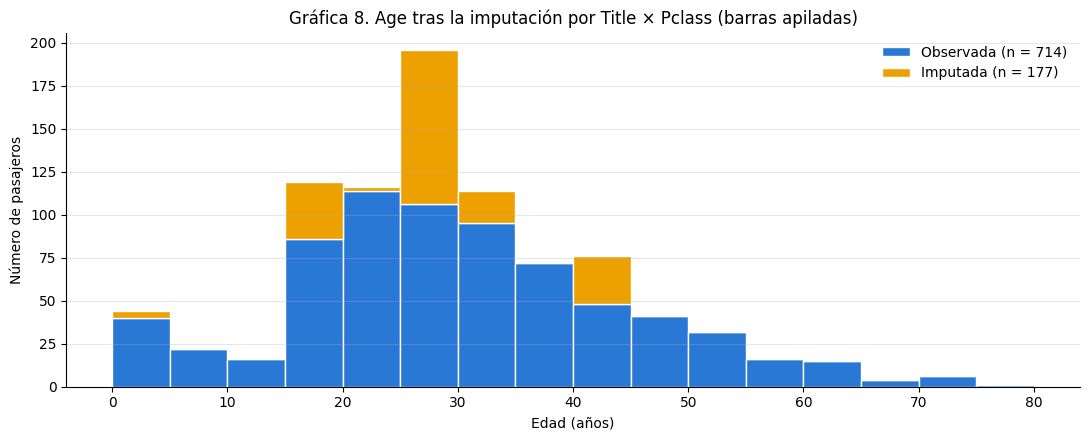

In [22]:
# Derivación de Title e imputación de Age por Title × Pclass
titulo_crudo = limpio["Name"].str.extract(r",\s*([^\.]+)\.")[0].str.strip()
print(f"Nombres sin título reconocible: {titulo_crudo.isna().sum()}")
EQUIVALENTES = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}  # equivalencias en francés / forma neutra
limpio["Title"] = titulo_crudo.replace(EQUIVALENTES)
limpio.loc[~limpio["Title"].isin(["Mr", "Mrs", "Miss", "Master"]), "Title"] = "Otro"
display(pd.DataFrame({"Títulos originales agrupados": titulo_crudo.groupby(limpio["Title"]).apply(
                          lambda s: ", ".join(f"{t} ({n})" for t, n in s.value_counts().items())),
                      "Pasajeros": limpio["Title"].value_counts()}).sort_values("Pasajeros", ascending=False))

# Medianas por Title × Pclass calculadas solo con edades observadas
medianas_age = limpio.groupby(["Title", "Pclass"])["Age"].median()
limpio["EdadImputada"] = limpio["Age"].isna()
imputacion = limpio[limpio["EdadImputada"]].groupby(["Title", "Pclass"]).size().rename("Imputadas").to_frame()
imputacion["Edades observadas en el grupo"] = limpio[~limpio["EdadImputada"]].groupby(["Title", "Pclass"]).size()
imputacion["Valor imputado (mediana)"] = medianas_age
display(imputacion)

limpio.loc[limpio["EdadImputada"], "Age"] = (
    limpio.loc[limpio["EdadImputada"]].set_index(["Title", "Pclass"]).index.map(medianas_age))
print(f"Imputadas {limpio['EdadImputada'].sum()} edades con la mediana de su grupo Title × Pclass; "
      f"faltantes restantes en Age: {limpio['Age'].isna().sum()}")

# Distribución resultante: edades observadas frente a imputadas
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.hist([limpio.loc[~limpio["EdadImputada"], "Age"], limpio.loc[limpio["EdadImputada"], "Age"]],
        bins=range(0, 85, 5), stacked=True, color=["#2a78d6", "#eda100"], edgecolor="white",
        label=[f"Observada (n = {(~limpio['EdadImputada']).sum()})", f"Imputada (n = {limpio['EdadImputada'].sum()})"])
ax.set_title("Gráfica 8. Age tras la imputación por Title × Pclass (barras apiladas)")
ax.set_xlabel("Edad (años)")
ax.set_ylabel("Número de pasajeros")
ax.set_xticks(range(0, 85, 10))
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

registrar(
    hallazgo="Age faltante en 177 pasajeros (19.87 %), concentrado en 3.ª clase (completitud)",
    deteccion="Sección 2, completitud y gráfica 4",
    evidencia="136 de 177 faltantes en 3.ª clase; mediana de Mr: 40 en 1.ª, 31 en 2.ª, 26 en 3.ª",
    accion=f"Imputadas {limpio['EdadImputada'].sum()} edades con la mediana por Title × Pclass; "
           "bandera EdadImputada (no será ítem); Title agrupado en Mr, Mrs, Miss, Master y Otro",
)

**Decisión 4.5: `Title` en 5 grupos e imputación de `Age` con la mediana por `Title` × `Pclass`**

*Title.* Todos los nombres tienen un título reconocible (**0** sin título). Se agrupan así:
- **Mlle y Ms → Miss**, y **Mme → Mrs**, por ser equivalentes.
- Los 10 títulos raros (Dr 7, Rev 6, Col 2, Major 2, Don, Sir, Lady, Capt, the Countess y Jonkheer) → **Otro**, con 23 pasajeros (2.58 %).

Quedan **Mr 517, Miss 185, Mrs 126, Master 40 y Otro 23**.

*Imputación de Age.*
- **Se imputaron 177 edades** con la mediana de las edades observadas en su grupo `Title` × `Pclass`. Faltantes restantes: **0**.
- Todos los grupos con faltantes tienen al menos **14** edades observadas.
- Los valores imputados van de **4.0** (Master de 3.ª) a **48.5** (Otro de 1.ª). La mediana global habría puesto a los 177 en 28.
- La bandera **`EdadImputada`** marca las 177 filas. **No será un ítem**; sirve para comprobar en el notebook 2 si las reglas con `Age` cambian al excluirlas.
- **Efecto visible (gráfica 8):** los **90** `Mr` de 3.ª clase reciben **26 años**, lo que crea un pico en el intervalo de 25–30.
  - Esto refuerza la asociación que ya existe entre ser hombre adulto de 3.ª clase y esas edades.
  - Es un efecto menor que el de la mediana global, pero hay que tenerlo presente al interpretar reglas que combinen `Age`, `Sex=male` y `Pclass=3`.

**Alternativas descartadas:**
| Alternativa | Razón para descartarla |
|---|---|
| Mediana global (28) | Concentra a los 177 pasajeros, mayoritariamente de 3.ª clase y no sobrevivientes, en un solo valor: crea asociaciones artificiales. |
| Ítem explícito `Age=Desconocida` | Con un 19.87 % de soporte y asociación con 3.ª clase y `Survived=0`, generaría reglas que reflejan el proceso de registro, no el fenómeno. |
| Mediana solo por `Title` | Ignora la clase, que es justo de lo que dependen los faltantes (p. ej. todos los `Mr` recibirían 30). |
| Muestreo aleatorio dentro del grupo | Conserva la forma de la distribución, pero introduce ruido aleatorio y las reglas dependerían de la semilla. |
| Mantener los 17 títulos | Los títulos raros tienen n = 1 o 2: su mediana no es fiable y como ítems nunca serían frecuentes. |

**Estado al cierre de la limpieza:** `limpio` conserva las **891 filas** (0 eliminadas) y no tiene faltantes. La bitácora acumula **6 entradas**.

In [23]:
# Estado de la copia de trabajo al cierre de la limpieza
estado = pd.DataFrame({"Tipo": limpio.dtypes.astype(str), "Nulos": limpio.isna().sum()})
display(estado)
print(f"limpio: {limpio.shape[0]} filas x {limpio.shape[1]} columnas | filas eliminadas en la sección 4: "
      f"{len(train) - len(limpio)} | entradas en la bitácora: {len(bitacora)}")

,Tipo,Nulos
PassengerId,int64,0
Survived,int64,0
Pclass,int64,0
Name,object,0
Sex,object,0
Age,float64,0
SibSp,int64,0
Parch,int64,0
Ticket,object,0
Fare,float64,0


limpio: 891 filas x 14 columnas | filas eliminadas en la sección 4: 0 | entradas en la bitácora: 6


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">PREPROCESAMIENTO · REDUCCIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">5. Reducción: redundancia entre atributos</span></div>

En reglas de asociación, dos atributos muy asociados entre sí producen **reglas triviales** (p. ej. `Fare=bajo → Pclass=3`) que inflan la lista de reglas sin aportar conocimiento. Aquí se mide la asociación entre pares de atributos categóricos con la **V de Cramér**, derivada del estadístico chi-cuadrado:

$$V = \sqrt{\frac{\chi^2 / n}{\min(r - 1,\, c - 1)}}$$

donde $n$ es el número de pasajeros y $r$, $c$ son los números de categorías de cada atributo. $V$ va de 0 (independencia) a 1 (asociación perfecta). Para poder medirla, `Age` y `Fare` se discretizan con los cortes elegidos para la sección 6, y `SibSp` y `Parch` se resumen en `FamilySize`.

Cortes de Fare (cuartiles): [0.0, 7.91, 14.45, 31.0, 512.33]


,Pasajeros,% soporte,% sobrevivió
FamilySize,,,
Solo,537,60.27,30.35
2-4,292,32.77,57.88
5+,62,6.96,16.13


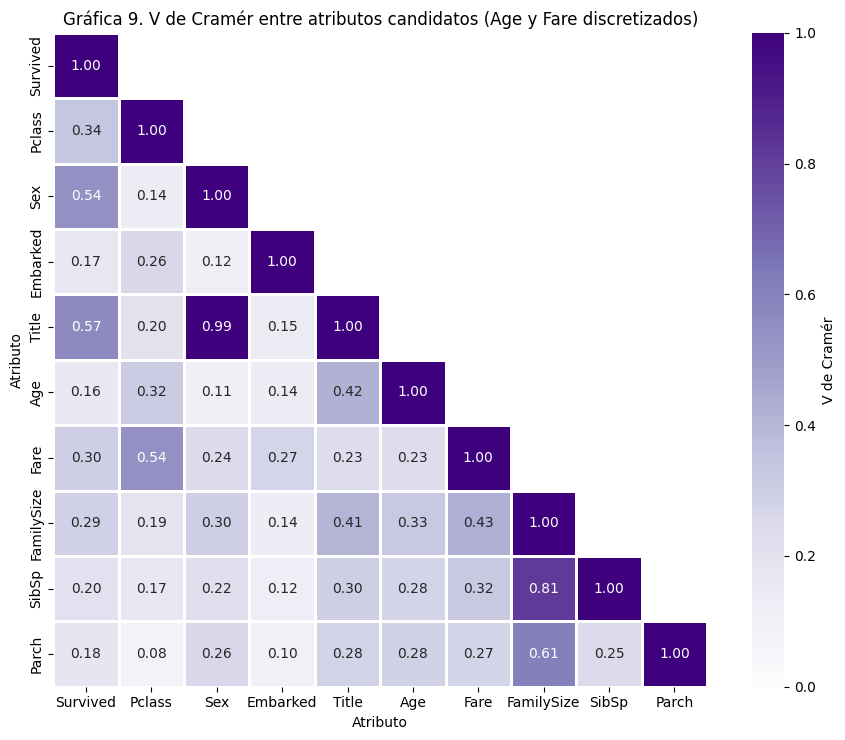

,,V de Cramér
Title,Sex,0.994
SibSp,FamilySize,0.815
Parch,FamilySize,0.612
Title,Survived,0.569
Sex,Survived,0.543
Fare,Pclass,0.540
FamilySize,Fare,0.429
Age,Title,0.418
FamilySize,Title,0.408
Pclass,Survived,0.340


In [24]:
# FamilySize y V de Cramér entre los atributos candidatos
from scipy.stats import chi2_contingency

# Cortes aprobados (se reutilizan en la sección 6)
CORTES_AGE = [0, 12, 17, 29, 49, np.inf]
ETIQUETAS_AGE = ["Niño (0-12)", "Adolescente (13-17)", "Joven (18-29)", "Adulto (30-49)", "Mayor (50+)"]
CORTES_FARE = limpio["Fare"].quantile([0, 0.25, 0.5, 0.75, 1]).tolist()
ETIQUETAS_FARE = [f"{CORTES_FARE[i]:.2f}-{CORTES_FARE[i + 1]:.2f}" for i in range(4)]
print(f"Cortes de Fare (cuartiles): {[round(c, 2) for c in CORTES_FARE]}")

# FamilySize = SibSp + Parch + 1, agrupado
limpio["FamilySize"] = limpio["SibSp"] + limpio["Parch"] + 1
GRUPO_FAMILIA = pd.cut(limpio["FamilySize"], [0, 1, 4, np.inf], labels=["Solo", "2-4", "5+"])
display(pd.DataFrame({"Pasajeros": GRUPO_FAMILIA.value_counts(sort=False),
                      "% soporte": (GRUPO_FAMILIA.value_counts(sort=False, normalize=True) * 100).round(2),
                      "% sobrevivió": (limpio["Survived"].groupby(GRUPO_FAMILIA, observed=False).mean() * 100).round(2)})
        .rename_axis("FamilySize"))


def v_cramer(x, y):
    """
    Calcula la V de Cramér entre dos variables categóricas.

    Parámetros
    ----------
    x, y : pd.Series
        Variables categóricas alineadas (mismo índice).

    Retorna
    -------
    float
        V de Cramér, entre 0 (independencia) y 1 (asociación perfecta).

    Notas
    -----
    Usa el chi-cuadrado sin corrección de continuidad, de modo que las tablas 2x2
    reciban el mismo tratamiento que las mayores.
    """
    tabla = pd.crosstab(x, y)
    chi2 = chi2_contingency(tabla, correction=False)[0]
    return np.sqrt(chi2 / tabla.values.sum() / (min(tabla.shape) - 1))


candidatos = pd.DataFrame({
    "Survived": limpio["Survived"], "Pclass": limpio["Pclass"], "Sex": limpio["Sex"],
    "Embarked": limpio["Embarked"], "Title": limpio["Title"],
    "Age": pd.cut(limpio["Age"], CORTES_AGE, labels=ETIQUETAS_AGE),
    "Fare": pd.cut(limpio["Fare"], CORTES_FARE, labels=ETIQUETAS_FARE, include_lowest=True),
    "FamilySize": GRUPO_FAMILIA, "SibSp": limpio["SibSp"], "Parch": limpio["Parch"],
})
matriz_v = pd.DataFrame({a: {b: v_cramer(candidatos[a], candidatos[b]) for b in candidatos} for a in candidatos})

fig, ax = plt.subplots(figsize=(9.5, 7.5))
mascara = np.triu(np.ones_like(matriz_v, dtype=bool), k=1)
sns.heatmap(matriz_v, mask=mascara, annot=True, fmt=".2f", cmap="Purples", vmin=0, vmax=1, square=True,
            linewidths=1, linecolor="white", cbar_kws={"label": "V de Cramér"}, ax=ax)
ax.set_title("Gráfica 9. V de Cramér entre atributos candidatos (Age y Fare discretizados)")
ax.set_xlabel("Atributo")
ax.set_ylabel("Atributo")
plt.tight_layout()
plt.show()

# Pares más asociados (sin la diagonal)
pares = (matriz_v.where(~np.triu(np.ones_like(matriz_v, dtype=bool))).stack()
         .rename("V de Cramér").sort_values(ascending=False).round(3))
display(pares.head(10).to_frame())

**Observaciones y decisiones de reducción (gráfica 9)**

- **`Title` y `Sex` son casi el mismo atributo (V = 0.994).** `Mr` y `Master` son hombres, y `Mrs` y `Miss` son mujeres; solo "Otro" mezcla ambos sexos.
  - **Decisión:** se conserva **`Sex`** como ítem y **`Title` no entra a las transacciones**. Su función ya se cumplió: sirvió para imputar `Age` (sección 4.5).
  - Su información adicional es pequeña frente a `Sex` (V con `Survived` de **0.57** contra **0.54**). Lo más útil es `Master`, los niños varones, y eso queda representado por `{Sex=male, Age=Niño}`.
  - *Alternativa descartada:* conservar ambos y filtrar reglas en el notebook 2. Cada itemset con `Title` llevaría a `Sex` implícito, lo que duplica itemsets y genera reglas como `Title=Mr → Sex=male` con confianza cercana al 100 %.
- **`FamilySize` resume a `SibSp` y `Parch`** (V = **0.815** y **0.612**). Por eso **reemplaza a ambos** (reducción de redundancia).
  - Agrupado en *Solo* (**60.27 %**, sobrevivió el 30.35 %), *2-4* (**32.77 %**, 57.88 %) y *5+* (**6.96 %**, 16.13 %), todos los grupos superan el 5 % de soporte. Con `SibSp` y `Parch` sueltos, 9 valores quedaban por debajo del 5 % (gráfica 3).
  - *Alternativa descartada:* conservar `SibSp` y `Parch` agrupados por separado. Sus ítems `=0` serían dominantes (68 % y 76 %) y redundantes entre sí.
- **`Fare` y `Pclass` tienen una asociación moderada (V = 0.540).** Se conservan **ambos**: `Fare` incluye información que `Pclass` no tiene (el tamaño del grupo, por ser el total del boleto; V con `FamilySize` = **0.429**) y la variación dentro de cada clase.
  - Las reglas que solo relacionen `Fare` con `Pclass` se marcarán como **triviales** en el notebook 2.
- **`Age` y `Title` (V = 0.418)** se asocian por construcción (`Age` se imputó por `Title`). Al no entrar `Title`, esto no genera reglas.
- **Asociación con `Survived`:** las más fuertes son con `Sex` (**0.54**) y `Pclass` (**0.34**), seguidas de `Fare` (**0.30**) y `FamilySize` (**0.29**). `Embarked` (**0.17**) y `Age` (**0.16**) tienen una asociación débil.

**Atributos finales para las transacciones (7):** `Survived`, `Pclass`, `Sex`, `Embarked`, `Age`, `Fare` y `FamilySize`.

In [25]:
# Registro de las decisiones de reducción
ATRIBUTOS = ["Survived", "Pclass", "Sex", "Embarked", "Age", "Fare", "FamilySize"]
registrar(
    hallazgo="SibSp y Parch redundantes con FamilySize; 9 de sus valores con soporte < 5 % (reducción)",
    deteccion="Sección 2, gráfica 3; sección 5, gráfica 9",
    evidencia=f"V(SibSp, FamilySize) = {matriz_v.loc['SibSp', 'FamilySize']:.3f}; "
              f"V(Parch, FamilySize) = {matriz_v.loc['Parch', 'FamilySize']:.3f}",
    accion="SibSp y Parch reemplazados por FamilySize = SibSp + Parch + 1, agrupado en Solo / 2-4 / 5+",
)
registrar(
    hallazgo="Title casi equivalente a Sex (reducción)",
    deteccion="Sección 5, gráfica 9",
    evidencia=f"V(Title, Sex) = {matriz_v.loc['Title', 'Sex']:.3f}",
    accion="Title no entra a las transacciones (se usó solo para imputar Age); se conserva Sex",
)
print(f"Atributos finales ({len(ATRIBUTOS)}): {ATRIBUTOS} | entradas en la bitácora: {len(bitacora)}")

Atributos finales (7): ['Survived', 'Pclass', 'Sex', 'Embarked', 'Age', 'Fare', 'FamilySize'] | entradas en la bitácora: 8


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">PREPROCESAMIENTO · TRANSFORMACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">6. Transformación al formato transaccional</span></div>

Cada pasajero se convierte en una **transacción**: un conjunto de ítems de la forma `Atributo=valor`, uno por atributo. `Age` y `Fare` se discretizan con los cortes elegidos (etapas de vida y cuartiles), y `FamilySize` ya está agrupado. Los outliers de `Fare` quedan absorbidos en el último cuartil y los 15 `Fare = 0` en el primero. Al final se construye la tabla **one-hot booleana** (una columna por ítem) que espera `mlxtend`.

In [26]:
# Discretización, ítems Atributo=valor y tabla one-hot booleana
categorica = pd.DataFrame({
    "Survived": limpio["Survived"].astype(str),
    "Pclass": limpio["Pclass"].astype(str),
    "Sex": limpio["Sex"],
    "Embarked": limpio["Embarked"],
    "Age": pd.cut(limpio["Age"], CORTES_AGE, labels=ETIQUETAS_AGE).astype(str),
    "Fare": pd.cut(limpio["Fare"], CORTES_FARE, labels=ETIQUETAS_FARE, include_lowest=True).astype(str),
    "FamilySize": GRUPO_FAMILIA.astype(str),
}, index=limpio.index)[ATRIBUTOS]
print(f"Nulos tras discretizar: {categorica.isna().sum().sum()} | "
      f"Fare = 0 en el primer cuartil: {(categorica.loc[limpio['Fare'] == 0, 'Fare'] == ETIQUETAS_FARE[0]).all()}")

transacciones = pd.get_dummies(categorica, prefix_sep="=").astype(bool)
items_por_fila = transacciones.sum(axis=1)
print(f"Transacciones: {transacciones.shape[0]} | ítems distintos: {transacciones.shape[1]} | "
      f"ítems por transacción: {items_por_fila.min()}–{items_por_fila.max()} | "
      f"densidad: {transacciones.values.mean():.4f}")

# Soporte de cada ítem
soporte_items = (transacciones.mean() * 100).round(2).rename("% soporte").to_frame()
soporte_items.insert(0, "Atributo", soporte_items.index.str.split("=").str[0])
display(soporte_items.sort_values(["Atributo", "% soporte"], ascending=[True, False]))
print(f"Ítems con soporte < 5 %: {soporte_items.query('`% soporte` < 5').index.tolist()}")

registrar(
    hallazgo="Age y Fare continuos; los ítems requieren valores categóricos (transformación)",
    deteccion="Sección 2, gráfica 1",
    evidencia=f"Fare muy asimétrico (cuartiles {', '.join(f'{c:.2f}' for c in CORTES_FARE[1:4])}); "
              "efecto de la edad concentrado en niños varones (gráfica 6)",
    accion="Age en 5 etapas de vida (0-12, 13-17, 18-29, 30-49, 50+); Fare en cuartiles; "
           f"{transacciones.shape[1]} ítems one-hot para {transacciones.shape[0]} transacciones",
)

Nulos tras discretizar: 0 | Fare = 0 en el primer cuartil: True
Transacciones: 891 | ítems distintos: 22 | ítems por transacción: 7–7 | densidad: 0.3182


,Atributo,% soporte
Age=Joven (18-29),Age,44.44
Age=Adulto (30-49),Age,34.12
Age=Mayor (50+),Age,8.31
Age=Niño (0-12),Age,8.19
Age=Adolescente (13-17),Age,4.94
Embarked=S,Embarked,72.50
Embarked=C,Embarked,18.86
Embarked=Q,Embarked,8.64
FamilySize=Solo,FamilySize,60.27
FamilySize=2-4,FamilySize,32.77


Ítems con soporte < 5 %: ['Age=Adolescente (13-17)']


**Observaciones: transacciones resultantes**

- **891 transacciones con 22 ítems distintos.** Cada transacción tiene **exactamente 7 ítems**, uno por atributo, y la **densidad es 0.3182** (7/22). Son datos **densos** y de longitud fija, como se anticipó en la justificación de FP-Growth.
- **No quedan nulos.** Los **15 `Fare = 0`** quedaron en el primer cuartil (`Fare=0.00-7.91`), como se decidió.
- **Los cuartiles de Fare tienen soportes equilibrados** (24.92 %–25.14 %): ningún intervalo de tarifa es raro.
- **Hay ítems dominantes** que aparecerán en muchos itemsets:
  - `Embarked=S` (**72.50 %**), `Sex=male` (**64.76 %**), `Survived=0` (**61.62 %**);
  - `FamilySize=Solo` (**60.27 %**), `Pclass=3` (**55.11 %**).

  En el notebook 2, el **lift** será imprescindible para separar las asociaciones reales de la frecuencia base.
- **Solo un ítem queda por debajo del 5 %: `Age=Adolescente (13-17)` (4.94 %).** Con `min_support = 5 %` no aparecería en ningún itemset frecuente. `Age=Niño (0-12)` (**8.19 %**) sí supera el umbral, pero sus combinaciones (p. ej. con `Sex=male`) serán pequeñas (gráfica 6).

<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="background:#3D6FB0;color:#FFFFFF;border-radius:3px;padding:2px 9px;font-size:11px;letter-spacing:.6px;">PREPROCESAMIENTO · EXPORTACIÓN</span><br/><span style="color:#3D6FB0;font-size:21px;font-weight:700;">7. Exportación</span></div>

Se guardan los dos archivos que usará el notebook 2, en el **mismo orden de filas**:

- `titanic_limpio.csv`: la tabla categórica (`PassengerId`, los 7 atributos y la bandera `EdadImputada`, que permite el análisis de sensibilidad).
- `titanic_transacciones.csv`: la tabla one-hot booleana, con una columna por ítem, lista para `mlxtend`.

Después se vuelven a leer los archivos para verificar que se guardaron correctamente.

In [27]:
# Exportación a data/processed y verificación por relectura
RUTA_PROCESADOS = RUTA_DATOS / "processed"
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)

tabla_limpia = pd.concat([limpio[["PassengerId"]], categorica, limpio[["EdadImputada"]]], axis=1)
tabla_limpia.to_csv(RUTA_PROCESADOS / "titanic_limpio.csv", index=False)
transacciones.to_csv(RUTA_PROCESADOS / "titanic_transacciones.csv", index=False)

# Relectura y verificación
relectura_limpia = pd.read_csv(RUTA_PROCESADOS / "titanic_limpio.csv", dtype=str)
relectura_trans = pd.read_csv(RUTA_PROCESADOS / "titanic_transacciones.csv")
display(pd.DataFrame({
    "Archivo": ["titanic_limpio.csv", "titanic_transacciones.csv"],
    "Filas": [len(relectura_limpia), len(relectura_trans)],
    "Columnas": [relectura_limpia.shape[1], relectura_trans.shape[1]],
    "Tamaño (KB)": [round((RUTA_PROCESADOS / f).stat().st_size / 1024, 1)
                    for f in ["titanic_limpio.csv", "titanic_transacciones.csv"]],
}).set_index("Archivo"))
print(f"Transacciones: todas las columnas booleanas: {(relectura_trans.dtypes == bool).all()} | "
      f"idénticas a las de memoria: {relectura_trans.equals(transacciones.reset_index(drop=True))}")
print(f"Tabla limpia: idéntica a la de memoria: {relectura_limpia.equals(tabla_limpia.astype(str).reset_index(drop=True))}")
display(relectura_limpia.head())

,Filas,Columnas,Tamaño (KB)
Archivo,,,
titanic_limpio.csv,891,9,46.0
titanic_transacciones.csv,891,22,109.9


Transacciones: todas las columnas booleanas: True | idénticas a las de memoria: True
Tabla limpia: idéntica a la de memoria: True


,PassengerId,Survived,Pclass,Sex,Embarked,Age,Fare,FamilySize,EdadImputada
0,1,0,3,male,S,Joven (18-29),0.00-7.91,2-4,False
1,2,1,1,female,C,Adulto (30-49),31.00-512.33,2-4,False
2,3,1,3,female,S,Joven (18-29),7.91-14.45,Solo,False
3,4,1,1,female,S,Adulto (30-49),31.00-512.33,2-4,False
4,5,0,3,male,S,Adulto (30-49),7.91-14.45,Solo,False


<div style="border-left:4px solid #3D6FB0;padding:4px 0 6px 14px;margin:16px 0 6px 0;"><span style="color:#3D6FB0;font-size:21px;font-weight:700;">8. Bitácora de calidad</span></div>

Resumen de todos los hallazgos de calidad y de las acciones tomadas a lo largo del notebook, en el orden en que se resolvieron. Junto con las celdas de decisión, garantiza la **trazabilidad** de las transformaciones aplicadas a los datos.

In [28]:
# Bitácora de calidad completa
tabla_bitacora = pd.DataFrame(bitacora)
tabla_bitacora.index = range(1, len(tabla_bitacora) + 1)
display(tabla_bitacora.style
        .set_properties(**{"text-align": "left", "white-space": "normal", "vertical-align": "top"})
        .set_caption("Bitácora de calidad: Hallazgo | Detección | Evidencia | Acción"))
print(f"Entradas: {len(tabla_bitacora)} | filas de train: {len(train)} | filas exportadas: {len(tabla_limpia)} | "
      f"filas eliminadas: {len(train) - len(tabla_limpia)}")

,Hallazgo,Detección,Evidencia,Acción
1,Embarked faltante en 2 pasajeras (completitud),"Sección 2, perfilado de completitud","PassengerId [62, 830]; mismo boleto 113572 y cabina B28; serie 113xxx: 41 de 45 en S; fuente externa (Encyclopedia Titanica): embarcaron en Southampton",Imputado Embarked = 'S' en 2 filas; S pasa de 644 a 646
2,Fare = 0 en 15 pasajeros (exactitud),"Sección 2, validez; sección 3, reporte","15 pasajeros (1.68 %), las 3 clases; 4 tickets LINE y boletos consecutivos; sobrevivieron 1",Sin cambios (0 filas): se conservan como boletos sin costo reales; su representación se revisa en la sección 6
3,Pasajero 873: 1.ª clase con Fare = 5.00 y cabina compartida con otro boleto (consistencia),"Sección 2, gráfica 7; sección 4.2","Ticket 695, Embarked S; cabina B51 B53 B55 también asignada al boleto PC 17755 (Fare 512.33, Embarked C)",Sin cambios (0 filas): no se puede determinar si el error está en Fare o en Cabin; se documenta
4,Prefijos de Ticket escritos de varias formas (precisión),"Sección 3, chequeo de prefijos",52 tickets en variante no canónica (5.84 %); 10 prefijos con variantes,Creada la clave Ticket_norm con el prefijo canónico (52 filas reescritas); Ticket original intacto; misma partición en grupos
5,"Cabin faltante en 687 pasajeros (77.10 %), dependiente de la clase (completitud)","Sección 2, completitud y gráfica 4","De las 204 cabinas registradas, 176 son de 1.ª clase; las cubiertas A, B, C y T son 100 % de 1.ª clase; solo C y B superan el 5 % de soporte","Columna Cabin eliminada (891 filas, 1 columna); no se crean Deck ni TieneCabina (proxy de Pclass)"
6,"Age faltante en 177 pasajeros (19.87 %), concentrado en 3.ª clase (completitud)","Sección 2, completitud y gráfica 4","136 de 177 faltantes en 3.ª clase; mediana de Mr: 40 en 1.ª, 31 en 2.ª, 26 en 3.ª","Imputadas 177 edades con la mediana por Title × Pclass; bandera EdadImputada (no será ítem); Title agrupado en Mr, Mrs, Miss, Master y Otro"
7,SibSp y Parch redundantes con FamilySize; 9 de sus valores con soporte < 5 % (reducción),"Sección 2, gráfica 3; sección 5, gráfica 9","V(SibSp, FamilySize) = 0.815; V(Parch, FamilySize) = 0.612","SibSp y Parch reemplazados por FamilySize = SibSp + Parch + 1, agrupado en Solo / 2-4 / 5+"
8,Title casi equivalente a Sex (reducción),"Sección 5, gráfica 9","V(Title, Sex) = 0.994",Title no entra a las transacciones (se usó solo para imputar Age); se conserva Sex
9,Age y Fare continuos; los ítems requieren valores categóricos (transformación),"Sección 2, gráfica 1","Fare muy asimétrico (cuartiles 7.91, 14.45, 31.00); efecto de la edad concentrado en niños varones (gráfica 6)","Age en 5 etapas de vida (0-12, 13-17, 18-29, 30-49, 50+); Fare en cuartiles; 22 ítems one-hot para 891 transacciones"


Entradas: 9 | filas de train: 891 | filas exportadas: 891 | filas eliminadas: 0


**Observaciones: balance del preprocesamiento**

- **La bitácora registra 9 hallazgos con su acción.** Ninguna acción eliminó filas: las **891** transacciones de `train` llegan completas al notebook 2.
- **Cambios en los valores:**
  - **2** imputaciones de `Embarked`;
  - **177** imputaciones de `Age`, marcadas con `EdadImputada`;
  - **52** tickets normalizados en `Ticket_norm`, que no se exporta.
- **Cambios en las columnas:**
  - se descartó `Cabin`;
  - `SibSp` y `Parch` se reemplazaron por `FamilySize`;
  - `Title` se usó solo para imputar;
  - `Age` y `Fare` se discretizaron.
- **Casos documentados sin cambios:** los 15 `Fare = 0` y el pasajero 873.
- **Resultado:** **7 atributos y 22 ítems.** Las transacciones son densas y de longitud fija (7 ítems), y están listas para FP-Growth.

---

<div style="opacity:.72;font-size:12.5px;">
Antes de entregar: comprueba que el notebook corre de principio a fin con <b>Kernel &gt; Restart &amp; Run All</b> sin errores.
</div>